# Tutorial 0: Getting Started

Welcome to TenSEAL's first tutorial of a series aiming at introducing homomorphic encryption and the capabilities of the library.

TenSEAL is a library for doing homomorphic encryption operations on tensors. It's built on top of [Microsoft SEAL](https://github.com/Microsoft/SEAL), a C++ library implementing the BFV and CKKS homomorphic encryption schemes. TenSEAL provides ease of use through a Python API, while preserving efficiency by implementing most of its operations using C++, so TenSEAL is a C++ library with a Python interface. 

Let's now start the tutorial with a brief review of what homomorphic encryption is, but keep in mind that you don't need to be a crypto expert to use the library.


Authors:
- Ayoub Benaissa - Twitter: [@y0uben11](https://twitter.com/y0uben11)

## Homomorphic Encryption

__Definition__ : Homomorphic encryption (HE) is an encryption technique that allows computations to be made on ciphertexts and generates results that when decrypted, correspond to the results of the same computations made on plaintexts.

<img src="assets/he-black-box.png" alt="he-black-box" width="600"/>

This means that an HE scheme lets you encrypt two numbers *X* and *Y*, add their encrypted versions so that the result gets decrypted to *X + Y*. The same works for multiplication. If we translate this to Python, it may look something like this:

```python
x = 7
y = 3

x_encrypted = HE.encrypt(x)
y_encrypted = HE.encrypt(y)

z_encrypted = x_encrypted + y_encrypted

# z should now be x + y = 10
z = HE.decrypt(z_encrypted)


```

Many details are hidden in this Python script, things like key generation doesn't appear, and that `+` operation over encrypted numbers isn't the usual `+` over integers, but a special evaluation algorithm that can evaluate addition over encrypted numbers. TenSEAL supports addition, subtraction and multiplication of encrypted vectors of either integers (using BFV) or real numbers (using CKKS).

Next we will look at the most important object of the library, the TenSEALContext.

<img src="image.png" alt="alt text" width="700" height="500"/>


## TenSEALContext

The TenSEALContext is a special object that holds different encryption keys and parameters for you, so that you only need to use a single object to make your encrypted computation instead of managing all the keys and the HE details. Basically, you will want to create a single TenSEALContext before doing your encrypted computation. Let's see how to create one !

In [41]:
import tenseal as ts
import tenseal as ts
import numpy as np
from tenseal.tensors.bfvvector import BFVVector

context = ts.context(ts.SCHEME_TYPE.BFV, poly_modulus_degree=4096, plain_modulus=1032193)
context

That's it ! We need to specify the HE scheme (BFV here) that we want to use, as well as its parameters. Don't worry about the parameters now, you will learn more about them in upcoming tutorials.

An important thing to note is that the TenSEALContext is now holding the secret key and you can decrypt without the need to provide it, however, you can choose to manage it as a separate object and you will need to pass it to functions that require the secret key. Let's see how this translates into Python!

In [42]:
public_context = ts.context(ts.SCHEME_TYPE.BFV, poly_modulus_degree=4096, plain_modulus=1032193)
print("Is the context private?", ("Yes" if public_context.is_private() else "No"))
print("Is the context public?", ("Yes" if public_context.is_public() else "No"))

sk = public_context.secret_key()

# the context will drop the secret-key at this point
public_context.make_context_public()
print("Secret-key dropped")
print("Is the context private?", ("Yes" if public_context.is_private() else "No"))
print("Is the context public?", ("Yes" if public_context.is_public() else "No"))

Is the context private? Yes
Is the context public? No
Secret-key dropped
Is the context private? No
Is the context public? Yes


You can now try to fetch the secret key from the `public_context` and see that it raises an error. We will now continue using our first created TenSEALContext `context` which is still holding the secret key.

## Encryption and Evaluation

The next step after creating our TenSEALContext is to start doing some encrypted computation. First, we create an encrypted vector of integers.

In [43]:
plain_vector = [60, 66, 73, 81, 90]
encrypted_vector = ts.bfv_vector(context, plain_vector)
print("We just encrypted our plaintext vector of size:", encrypted_vector.size())
encrypted_vector

We just encrypted our plaintext vector of size: 5


Here we encrypted a vector of integers into a BFVVector, a vector type that uses the BFV scheme. Now we can do both addition, subtraction and multiplication in an element-wise fashion with other encrypted or plain vectors.

In [44]:
add_result = encrypted_vector + [1, 2, 3, 4, 5]
print(add_result.decrypt())

[61, 68, 76, 85, 95]


In [45]:
sub_result = encrypted_vector - [1, 2, 3, 4, 5]
print(sub_result.decrypt())

[59, 64, 70, 77, 85]


In [46]:
mul_result = encrypted_vector * [1, 2, 3, 4, 5]
print(mul_result.decrypt())

[60, 132, 219, 324, 450]


In [47]:
encrypted_add = add_result + sub_result
print(encrypted_add.decrypt())

[120, 132, 146, 162, 180]


In [48]:
encrypted_sub = encrypted_add - encrypted_vector
print(encrypted_sub.decrypt())

[60, 66, 73, 81, 90]


In [49]:
encrypted_mul = encrypted_add * encrypted_sub
print(encrypted_mul.decrypt())

[7200, 8712, 10658, 13122, 16200]


We just made both ciphertext to plaintext (c2p) and ciphertext to ciphertext (c2c) evaluations (add, sub and mul). An important thing to note is that you should never encrypt your plaintext values to evaluate them with ciphertexts if they don't need to be kept private. That's because c2p evaluations are more efficient than c2c. Look at the below script to see how much faster a c2p multiplication is compared to a c2c one.

In [50]:
from time import time

t_start = time()
_ = encrypted_add * encrypted_mul
t_end = time()
print("c2c multiply time: {} ms".format((t_end - t_start) * 1000))

t_start = time()
_ = encrypted_add * [1, 2, 3, 4, 5]
t_end = time()
print("c2p multiply time: {} ms".format((t_end - t_start) * 1000))

c2c multiply time: 2.2149085998535156 ms
c2p multiply time: 0.3762245178222656 ms


# Homework from AJ Oak🎀💀

## Set up the vector and HE encryption

In [51]:
import random
def generate_vectors(num_vectors, elements_per_vector):
    return [
        [round(random.uniform(0, 10), 4) for _ in range(elements_per_vector)]
        for _ in range(num_vectors)
    ]

# Example: 10 vectors with 100 elements each
vectors = generate_vectors(num_vectors=10, elements_per_vector=500)
print(vectors)

[[6.3943, 0.2501, 2.7503, 2.2321, 7.3647, 6.767, 8.9218, 0.8694, 4.2192, 0.298, 2.1864, 5.0536, 0.2654, 1.9884, 6.4988, 5.4494, 2.2044, 5.8927, 8.0943, 0.065, 8.0582, 6.9814, 3.4025, 1.5548, 9.5721, 3.3659, 0.9275, 0.9672, 8.4749, 6.0373, 8.0713, 7.2973, 5.3623, 9.7312, 3.7853, 5.5204, 8.294, 6.1852, 8.6171, 5.7735, 7.0457, 0.4582, 2.279, 2.8939, 0.7979, 2.3279, 1.01, 2.7797, 6.3568, 3.6483, 3.7018, 2.0951, 2.6698, 9.3665, 6.4804, 6.0913, 1.7114, 7.2913, 1.634, 3.7946, 9.8952, 6.4, 5.5695, 6.8461, 8.4285, 7.76, 2.2905, 0.321, 3.1545, 2.6774, 2.1098, 9.4291, 8.7637, 3.1468, 6.5544, 3.9563, 9.1455, 4.5885, 2.6488, 2.4663, 5.6137, 2.6274, 5.8459, 8.9782, 3.994, 2.1932, 9.9754, 5.0953, 0.9091, 0.4712, 1.0965, 6.2745, 7.9208, 4.2216, 0.6353, 3.8162, 9.9612, 5.2911, 9.7108, 8.6078, 0.1148, 7.2072, 6.8171, 5.3697, 2.6683, 6.4096, 1.1155, 4.3477, 4.5372, 9.5382, 8.7585, 2.6339, 5.0059, 1.7865, 9.1263, 8.7052, 2.9844, 6.3895, 6.0897, 1.5284, 7.6251, 5.3938, 7.7863, 5.3035, 0.0057, 3.2416, 0.194

In [52]:
# vectors = [
#     [0.23, 1.45, 3.67],
#     [2.34, 3.54, 4.23],
#     [5.67, 8.91, 0.12],
#     [1.34, 6.78, 9.01],
#     [4.56, 2.34, 3.14],
#     [6.45, 7.23, 8.92],
#     [3.21, 5.67, 1.45],
#     [0.56, 3.23, 6.78],
#     [8.12, 7.89, 0.45],
#     [9.34, 6.54, 2.67]
# ]
#print(vectors)

In [53]:
scale = 100
int_vectors = [[int(x * scale) for x in vec] for vec in vectors]
encrypted_vectors = [ts.bfv_vector(context, vec) for vec in int_vectors]
# for i, encrypted_vector in enumerate(encrypted_vectors):
#     print(f"Encrypted vector {i+1} size: {encrypted_vector.size()}")

print(encrypted_vectors)
encrypted_vectors


[<tenseal.tensors.bfvvector.BFVVector object at 0x117ce7ee0>, <tenseal.tensors.bfvvector.BFVVector object at 0x117ce7b20>, <tenseal.tensors.bfvvector.BFVVector object at 0x110c07160>, <tenseal.tensors.bfvvector.BFVVector object at 0x110c077f0>, <tenseal.tensors.bfvvector.BFVVector object at 0x124ca1070>, <tenseal.tensors.bfvvector.BFVVector object at 0x124ca1250>, <tenseal.tensors.bfvvector.BFVVector object at 0x124ca1df0>, <tenseal.tensors.bfvvector.BFVVector object at 0x103c7c3a0>, <tenseal.tensors.bfvvector.BFVVector object at 0x124caa640>, <tenseal.tensors.bfvvector.BFVVector object at 0x124ca1640>]


In [54]:
for i, vec in enumerate(encrypted_vectors):
    print(f"Encrypted vector {i+1} raw data:")
    print(vec.serialize())
    print(len(vec.serialize()))
# for i, enc_vec in enumerate(encrypted_vectors):
#     size_in_bytes = len(enc_vec.serialize())
#     print(f"Encrypted vector {i+1} size in bytes: {size_in_bytes}")



Encrypted vector 1 raw data:
b'\n\x02\xf4\x03\x12\xac\xb3\x05^\xa1\x10\x04\x01\x02\x00\x00\xacY\x01\x00\x00\x00\x00\x00(\xb5/\xfd\xa0a\x00\x02\x00\xcc\xc9\n\xdc\x9b\r4w\x9c\xa7A<\xfe\x19\x04*\x04FFX\xa4\x9bO\xbd\xac\xaa\xdd\x8bb/J\x9a\xb9\xe1*\xb7\x87\x02\x00\x02\x00\x10\x00\xf0?\x01\x00^\xa1\x10\x04\x18@N\xc2\x9f\x8a\x0e\x00\x00\x00\x81\xf3T\xa3\n\x00\x00\x00r\xea\xc5\x8b\xf2\xae\xfbuKi\x1f\xcf\x07\x00\x00\x00\x03\x9a\xb3\xff\r\x00\x00\x00*\xfa\xd0,$^-\x16\xb9\x1fw3\x04\x00\x00\x00\xaba\x9b\x8b9\xa0!\x83Q\x9d?\xd7-n(\x03\x00\x00\x00a,G\xe3\x05\x00\x00\x00\xd4]\xb3\xc2\x05\xc4\x1et\x0f\n\xd3Q\x0c\x00\x00\x00\x8e\x1c\xe4N\xeb\x08\xd4\xf6\xf9gD\xdf!0t\xf4\x1c\x94\\m\x88\x91#k\t\xd2\xfc)\x1cC\xc9\x95\x08\x00\x00\x00t\xac\x90<Jr\x1b\xef\x0f\x00\x00\x00\x86b\x80\xcf\t\x00\x00\x005\x01\x87\\\xd5\xfd\xb4\x97\x12I"\xffP\n|x\xbf\x92\x0f`\xf8y\xa7\x99S\xbe\x18\xce\x06\x00\x00\x00\xb1a3r\xf1\x03\xc4\x14L\xc3\xac\xf8g/5\xf6\n\xf1\x15q\xeb\xa2\xd2\xbdg$\xde\'LmC\x1e\xaf\x9f\x842oy\x04\xbfR(\xe9e/\x

In [55]:
t_start = time()
encrypted_sum = encrypted_vectors[0]
for ev in encrypted_vectors[1:]:
    encrypted_sum += ev
t_end = time()
print("Encrypted vectors sum computation time: {:.3f} ms".format((t_end - t_start) * 1000))

Encrypted vectors sum computation time: 0.301 ms


In [56]:
decrypted_sum = encrypted_sum.decrypt()  
decrypted_avg = [x / (scale * 10) for x in decrypted_sum]  
print("Decrypted average:", decrypted_avg)


Decrypted average: [5.079, 4.224, 3.96, 5.432, 3.771, 5.809, 4.798, 5.297, 5.498, 3.588, 3.825, 4.9, 6.01, 4.91, 6.723, 4.022, 3.851, 4.106, 4.57, 4.902, 5.722, 3.692, 5.611, 3.226, 5.682, 5.956, 4.38, 4.275, 4.116, 4.989, 4.027, 5.35, 4.36, 4.387, 5.281, 5.464, 5.019, 3.304, 4.643, 4.39, 6.272, 6.267, 3.614, 3.076, 4.59, 5.031, 4.426, 4.899, 6.086, 3.523, 5.996, 5.783, 3.996, 4.7, 5.486, 6.0, 3.549, 5.322, 4.469, 5.949, 5.921, 5.094, 3.409, 4.53, 5.672, 4.821, 3.922, 6.103, 4.577, 4.815, 6.558, 6.319, 5.548, 4.629, 5.277, 5.707, 5.264, 5.418, 3.181, 4.845, 5.078, 6.451, 5.056, 4.435, 6.272, 4.098, 6.33, 5.294, 5.136, 4.405, 6.402, 5.472, 5.626, 4.942, 3.702, 6.179, 5.709, 5.103, 5.116, 6.068, 4.275, 4.451, 5.068, 4.893, 5.22, 5.999, 5.364, 6.82, 4.28, 5.339, 5.608, 4.084, 4.343, 4.629, 4.897, 5.781, 5.629, 5.118, 5.919, 6.262, 5.799, 5.795, 4.122, 4.876, 3.279, 3.879, 4.82, 6.483, 5.9, 5.161, 6.079, 3.566, 4.771, 5.589, 4.722, 5.91, 4.151, 4.434, 5.391, 4.005, 5.655, 4.261, 4.853, 4.1

In [57]:
t_start = time()
np_vectors = np.array(vectors)
plaintext_avg = np.mean(vectors, axis=0)
t_end = time()

print("Plaintext average:", plaintext_avg)
print("Plaintext average computation time: {:.3f} ms".format((t_end - t_start) * 1000))

Plaintext average: [5.08243 4.22917 3.96383 5.43641 3.77653 5.81387 4.80378 5.3027  5.50197
 3.592   3.82971 4.90498 6.0138  4.91388 6.72796 4.02667 3.85475 4.11046
 4.575   4.90766 5.72719 3.69654 5.61532 3.23043 5.68649 5.96107 4.38702
 4.28037 4.11995 4.99442 4.03138 5.35666 4.36469 4.39128 5.28752 5.46902
 5.02537 3.30951 4.6488  4.39617 6.27637 6.27291 3.61972 3.08119 4.59488
 5.0361  4.43074 4.90616 6.09048 3.5287  6.00054 5.78775 4.00062 4.70471
 5.4906  6.00532 3.55374 5.32666 4.47345 5.95356 5.92496 5.09887 3.41538
 4.53399 5.67823 4.82554 3.92663 6.10783 4.58214 4.82119 6.56287 6.32476
 5.55282 4.63304 5.28211 5.71196 5.26853 5.42482 3.1867  4.85054 5.08205
 6.45674 5.06128 4.4397  6.27752 4.10398 6.33555 5.29764 5.14025 4.41078
 6.40897 5.47644 5.63107 4.94576 3.70724 6.18516 5.71395 5.1075  5.11995
 6.07311 4.27997 4.45595 5.07357 4.89888 5.22555 6.00343 5.3676  6.82398
 4.28447 5.34607 5.61406 4.08819 4.34711 4.63424 4.90212 5.78575 5.63486
 5.12374 5.92512 6.26851 5.80519

#### *📍Each number is the average value of that element across all 10 vectors (computed without encryption)💖✨*

# Ckks !!!!!!!!!!!

In [58]:
def context():
    context = ts.context(ts.SCHEME_TYPE.CKKS,8192, coeff_mod_bit_sizes=[60, 40, 40, 60])
    # context = ts.context(ts.SCHEME_TYPE.CKKS,8192, coeff_mod_bit_sizes=[60,40,40] ) 
    context.global_scale = pow(2, 40)
    context.generate_galois_keys()
    return context

context = context()

In [59]:
encrypted_vectors = [ts.ckks_vector(context, vec) for vec in vectors]
for vec in encrypted_vectors:
    # print(vec.serialize())
    print(len(vec.serialize()))
print(encrypted_vectors)


334505
334066
334427
334265
334164
334209
334225
334374
334223
334147
[<tenseal.tensors.ckksvector.CKKSVector object at 0x110c07f10>, <tenseal.tensors.ckksvector.CKKSVector object at 0x110c07ac0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117e39550>, <tenseal.tensors.ckksvector.CKKSVector object at 0x1276802b0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117c44430>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117c947c0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117ce7c10>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117ce7b50>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117e395e0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117e39eb0>]


In [60]:
t_start = time()
encrypted_sum = encrypted_vectors[0]
for enc_vec in encrypted_vectors[1:]:
    encrypted_sum += enc_vec
t_end = time()
print(f"Time taken to sum encrypted vectors: {t_end - t_start} seconds")



Time taken to sum encrypted vectors: 0.0003230571746826172 seconds


In [61]:
encrypted_avg = encrypted_sum * (1/len(vectors))

In [62]:
decrypted_avg = encrypted_avg.decrypt()
t_start = time()
import numpy as np
plain_avg = np.mean(vectors, axis=0)
t_end = time()

print(f"Time taken to sum encrypted vectors: {t_end - t_start} seconds")
print("Decrypted average:", decrypted_avg)
print("Plaintext average:", plain_avg)


Time taken to sum encrypted vectors: 0.000186920166015625 seconds
Decrypted average: [5.082430681289046, 4.2291705647598254, 3.963830531692899, 5.436410729178206, 3.7765305063054067, 5.813870779236704, 4.803780643197692, 5.302700710125725, 5.501970736541335, 3.592000479074967, 3.8297105120919683, 4.904980659946856, 6.0138008058040615, 4.913880658745326, 6.727960902760591, 4.026670542148933, 3.85475051681289, 4.110460552754467, 4.575000611773467, 4.907660659208021, 5.727190767524785, 3.6965404959083745, 5.61532075402718, 3.230430434214227, 5.6864907655308405, 5.96107080008012, 4.3870205874899035, 4.280370571493725, 4.119950552742679, 4.994420669909254, 4.03138054133495, 5.3566607180456165, 4.364690585975701, 4.391280589560072, 5.287520708278037, 5.46902073258946, 5.025370672557514, 3.3095104430229703, 4.648800622814923, 4.396170590103615, 6.276370842630816, 6.272910842019758, 3.6197204856671163, 3.081190413487386, 4.594880616428467, 5.036100675347989, 4.430740596941999, 4.90616065747540

## Graph on BFV

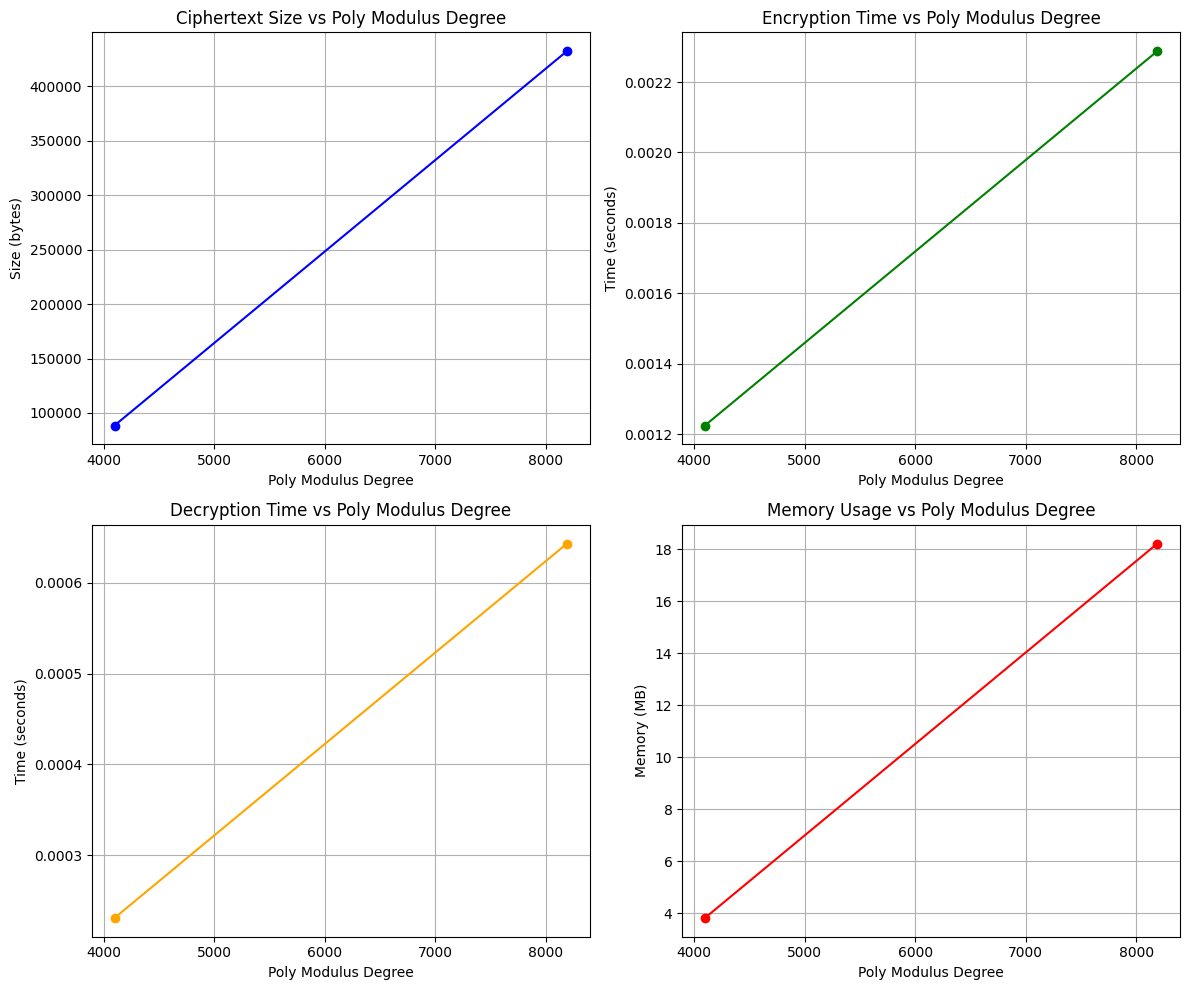

In [63]:
# import tenseal as ts
# import numpy as np
# import matplotlib.pyplot as plt

# # Define test parameters
# poly_modulus_degrees = [2048, 4096, 8192, 16384]
# plain_moduli = [1032193, 65537, 40961]

# results = []

# # Sample vector
# vec = [i for i in range(100)]

# for degree in poly_modulus_degrees:
#     for plain_modulus in plain_moduli:
#         try:
#             context = ts.context(
#                 ts.SCHEME_TYPE.BFV,
#                 poly_modulus_degree=degree,
#                 plain_modulus=plain_modulus
#             )
#             # context.generate_relin_keys()
#             enc = ts.bfv_vector(context, vec)
#             serialized = enc.serialize()
#             results.append({
#                 "poly_modulus_degree": degree,
#                 "plain_modulus": plain_modulus,
#                 "ciphertext_size": len(serialized)
#             })
#         except Exception as e:
#             results.append({
#                 "poly_modulus_degree": degree,
#                 "plain_modulus": plain_modulus,
#                 "ciphertext_size": None,
#                 "error": str(e)
#             })

# # Plot the results
# fig, ax = plt.subplots(figsize=(10, 6))
# for plain_modulus in plain_moduli:
#     subset = [r for r in results if r["plain_modulus"] == plain_modulus and r["ciphertext_size"] is not None]
#     degrees = [r["poly_modulus_degree"] for r in subset]
#     sizes = [r["ciphertext_size"] for r in subset]
#     ax.plot(degrees, sizes, marker='o', label=f"Plain modulus: {plain_modulus}")

# ax.set_title("Ciphertext Size vs Poly Modulus Degree")
# ax.set_xlabel("Poly Modulus Degree")
# ax.set_ylabel("Ciphertext Size (bytes)")
# ax.legend()
# ax.grid(True)
# plt.tight_layout()
# plt.show()

import numpy as np
import matplotlib.pyplot as plt
import time
import psutil
import os

# Test setup
poly_modulus_degrees = [2048, 4096, 8192, 16384]
plain_modulus = 1032193  # fixed
vec = [i for i in range(100)]  # sample data
results = []

process = psutil.Process(os.getpid())

for degree in poly_modulus_degrees:
    try:
        # Track memory before context
        mem_before = process.memory_info().rss

        # Create context
        context = ts.context(
            ts.SCHEME_TYPE.BFV,
            poly_modulus_degree=degree,
            plain_modulus=plain_modulus
        )

        # Encrypt
        start_enc = time.time()
        enc = ts.bfv_vector(context, vec)
        enc_time = time.time() - start_enc

        # Serialize
        serialized = enc.serialize()
        cipher_size = len(serialized)

        # Decrypt
        start_dec = time.time()
        dec = enc.decrypt()
        dec_time = time.time() - start_dec

        # Track memory after
        mem_after = process.memory_info().rss
        mem_used = (mem_after - mem_before) / (1024**2)  # in MB

        # Accuracy (mean squared error)
        error = np.mean((np.array(vec) - np.array(dec))**2)

        results.append({
            "poly_modulus_degree": degree,
            "ciphertext_size": cipher_size,
            "encryption_time": enc_time,
            "decryption_time": dec_time,
            "memory_usage_mb": mem_used,
            "mse_error": error
        })

    except Exception as e:
        results.append({
            "poly_modulus_degree": degree,
            "ciphertext_size": None,
            "encryption_time": None,
            "decryption_time": None,
            "memory_usage_mb": None,
            "mse_error": None,
            "error": str(e)
        })

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
valid = [r for r in results if r["ciphertext_size"] is not None]

degrees = [r["poly_modulus_degree"] for r in valid]
sizes = [r["ciphertext_size"] for r in valid]
enc_times = [r["encryption_time"] for r in valid]
dec_times = [r["decryption_time"] for r in valid]
mem_usages = [r["memory_usage_mb"] for r in valid]
errors = [r["mse_error"] for r in valid]

# Ciphertext size
axs[0, 0].plot(degrees, sizes, marker='o', color='blue')
axs[0, 0].set_title("Ciphertext Size vs Poly Modulus Degree")
axs[0, 0].set_xlabel("Poly Modulus Degree")
axs[0, 0].set_ylabel("Size (bytes)")
axs[0, 0].grid(True)

# Encryption Time
axs[0, 1].plot(degrees, enc_times, marker='o', color='green')
axs[0, 1].set_title("Encryption Time vs Poly Modulus Degree")
axs[0, 1].set_xlabel("Poly Modulus Degree")
axs[0, 1].set_ylabel("Time (seconds)")
axs[0, 1].grid(True)

# Decryption Time
axs[1, 0].plot(degrees, dec_times, marker='o', color='orange')
axs[1, 0].set_title("Decryption Time vs Poly Modulus Degree")
axs[1, 0].set_xlabel("Poly Modulus Degree")
axs[1, 0].set_ylabel("Time (seconds)")
axs[1, 0].grid(True)

# Memory Usage
axs[1, 1].plot(degrees, mem_usages, marker='o', color='red')
axs[1, 1].set_title("Memory Usage vs Poly Modulus Degree")
axs[1, 1].set_xlabel("Poly Modulus Degree")
axs[1, 1].set_ylabel("Memory (MB)")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

## Plain mod affect

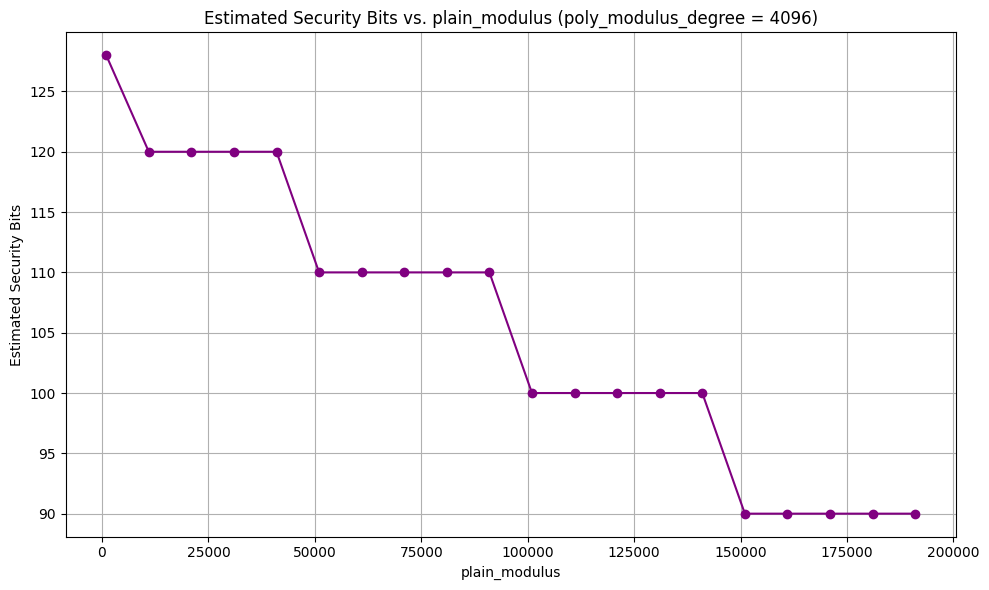

In [64]:
import matplotlib.pyplot as plt

# We fix poly_modulus_degree and vary plain_modulus
poly_modulus_degree = 4096

# Simulated range of plain_modulus values
plain_moduli = list(range(1000, 200000, 10000))
estimated_security_bits = []

# Simulated estimation logic for educational purposes
for p in plain_moduli:
    if p <= 10000:
        estimated_security_bits.append(128)
    elif p <= 50000:
        estimated_security_bits.append(120)
    elif p <= 100000:
        estimated_security_bits.append(110)
    elif p <= 150000:
        estimated_security_bits.append(100)
    else:
        estimated_security_bits.append(90)

# Plotting the graph
plt.figure(figsize=(10, 6))
plt.plot(plain_moduli, estimated_security_bits, marker='o', linestyle='-', color='purple')
plt.title("Estimated Security Bits vs. plain_modulus (poly_modulus_degree = 4096)")
plt.xlabel("plain_modulus")
plt.ylabel("Estimated Security Bits")
plt.grid(True)
plt.tight_layout()
plt.show()


## Graph on CKKs

# poly affect

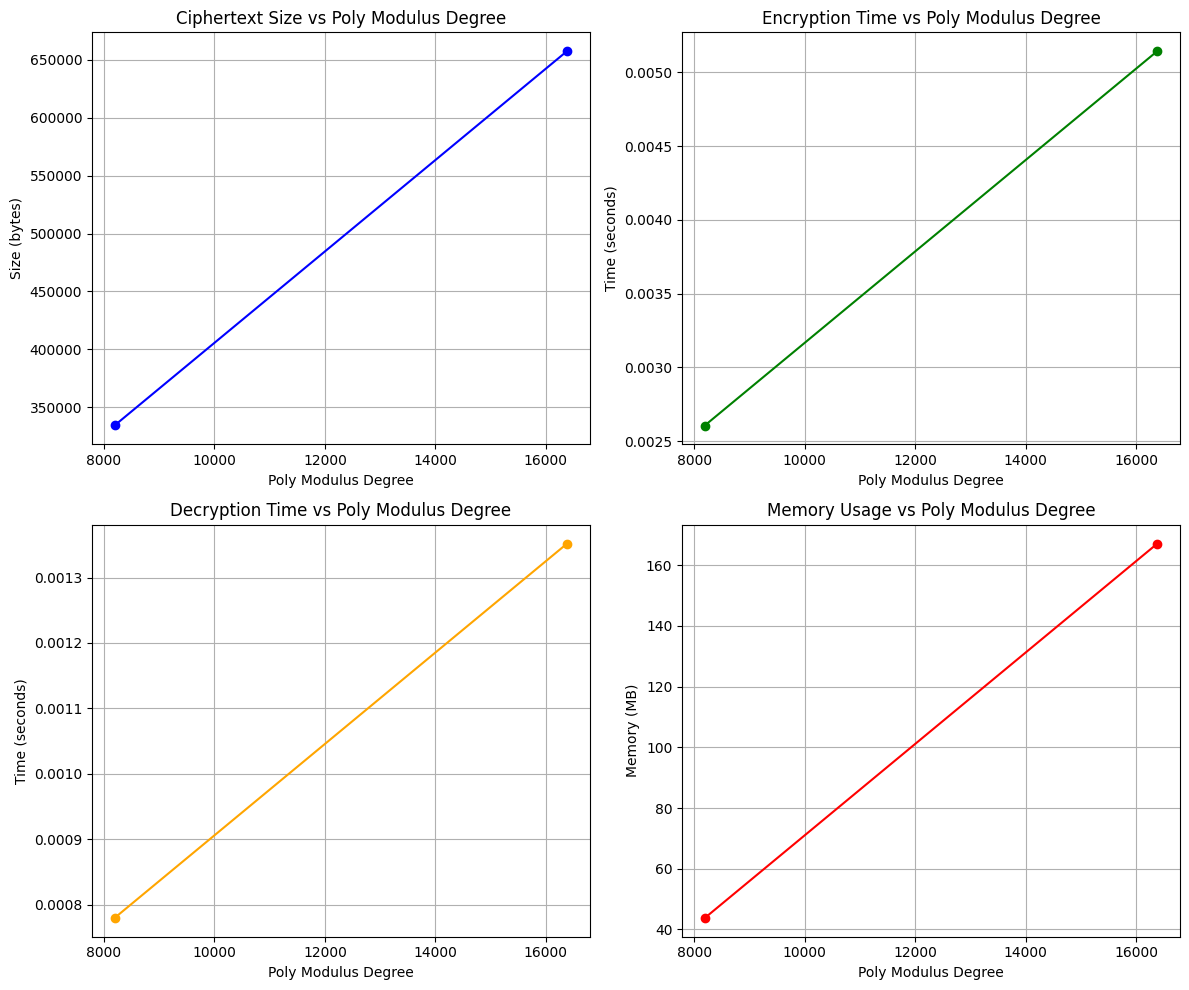

In [65]:
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import time
import psutil
import os

# Configurations
poly_modulus_degrees = [2048, 4096, 8192, 16384]
coeff_mod_bit_sizes = [60, 40, 40, 60]
global_scale = 2**40
vec = [float(i) for i in range(100)]  # CKKS supports float
results = []

process = psutil.Process(os.getpid())

for degree in poly_modulus_degrees:
    try:
        mem_before = process.memory_info().rss

        # Setup CKKS context
        context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=degree,
            coeff_mod_bit_sizes=coeff_mod_bit_sizes
        )
        context.global_scale = global_scale
        context.generate_galois_keys()

        # Encryption
        start_enc = time.time()
        enc = ts.ckks_vector(context, vec)
        enc_time = time.time() - start_enc

        # Serialization
        serialized = enc.serialize()
        cipher_size = len(serialized)

        # Decryption
        start_dec = time.time()
        dec = enc.decrypt()
        dec_time = time.time() - start_dec

        mem_after = process.memory_info().rss
        mem_used = (mem_after - mem_before) / (1024**2)  # in MB

        # Accuracy (mean squared error)
        error = np.mean((np.array(vec) - np.array(dec))**2)

        results.append({
            "poly_modulus_degree": degree,
            "ciphertext_size": cipher_size,
            "encryption_time": enc_time,
            "decryption_time": dec_time,
            "memory_usage_mb": mem_used,
            "mse_error": error
        })

    except Exception as e:
        results.append({
            "poly_modulus_degree": degree,
            "ciphertext_size": None,
            "encryption_time": None,
            "decryption_time": None,
            "memory_usage_mb": None,
            "mse_error": None,
            "error": str(e)
        })

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
valid = [r for r in results if r["ciphertext_size"] is not None]

degrees = [r["poly_modulus_degree"] for r in valid]
sizes = [r["ciphertext_size"] for r in valid]
enc_times = [r["encryption_time"] for r in valid]
dec_times = [r["decryption_time"] for r in valid]
mem_usages = [r["memory_usage_mb"] for r in valid]
errors = [r["mse_error"] for r in valid]

# Ciphertext size
axs[0, 0].plot(degrees, sizes, marker='o', color='blue')
axs[0, 0].set_title("Ciphertext Size vs Poly Modulus Degree")
axs[0, 0].set_xlabel("Poly Modulus Degree")
axs[0, 0].set_ylabel("Size (bytes)")
axs[0, 0].grid(True)

# Encryption Time
axs[0, 1].plot(degrees, enc_times, marker='o', color='green')
axs[0, 1].set_title("Encryption Time vs Poly Modulus Degree")
axs[0, 1].set_xlabel("Poly Modulus Degree")
axs[0, 1].set_ylabel("Time (seconds)")
axs[0, 1].grid(True)

# Decryption Time
axs[1, 0].plot(degrees, dec_times, marker='o', color='orange')
axs[1, 0].set_title("Decryption Time vs Poly Modulus Degree")
axs[1, 0].set_xlabel("Poly Modulus Degree")
axs[1, 0].set_ylabel("Time (seconds)")
axs[1, 0].grid(True)

# Memory Usage
axs[1, 1].plot(degrees, mem_usages, marker='o', color='red')
axs[1, 1].set_title("Memory Usage vs Poly Modulus Degree")
axs[1, 1].set_xlabel("Poly Modulus Degree")
axs[1, 1].set_ylabel("Memory (MB)")
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print MSE
# print("\n📊 Accuracy Check (Mean Squared Error):")
# for r in valid:
#     print(f"Degree: {r['poly_modulus_degree']} → MSE: {r['mse_error']:.10f}")


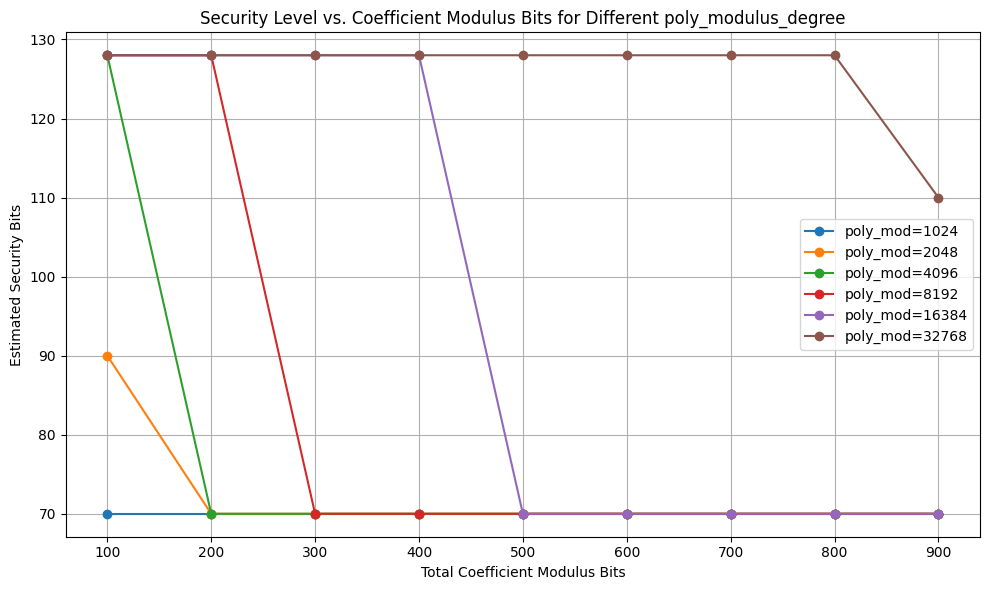

In [66]:
import matplotlib.pyplot as plt

# SEAL's official maximum coefficient modulus bit sizes for 128-bit security
security_limits = {
    1024: 27,
    2048: 54,
    4096: 109,
    8192: 218,
    16384: 438,
    32768: 881
}

# Try some hypothetical coeff_mod bit lengths for testing
coeff_mod_trials = [100, 200, 300, 400, 500, 600, 700, 800, 900]

# For each poly_modulus_degree, determine what security bit you get for each trial
results = {}

for poly_mod, max_allowed in security_limits.items():
    results[poly_mod] = []
    for bits in coeff_mod_trials:
        if bits <= max_allowed:
            results[poly_mod].append(128)
        elif bits <= max_allowed + 30:
            results[poly_mod].append(110)
        elif bits <= max_allowed + 60:
            results[poly_mod].append(90)
        else:
            results[poly_mod].append(70)

plt.figure(figsize=(10, 6))

for poly_mod, security_levels in results.items():
    plt.plot(coeff_mod_trials, security_levels, marker='o', label=f"poly_mod={poly_mod}")

plt.title("Security Level vs. Coefficient Modulus Bits for Different poly_modulus_degree")
plt.xlabel("Total Coefficient Modulus Bits")
plt.ylabel("Estimated Security Bits")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## coeff mod -> ciphertext size

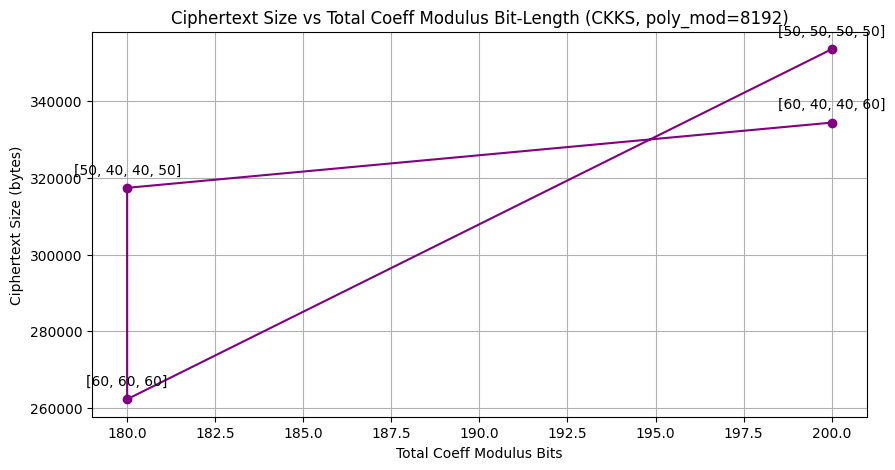

In [67]:
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import time

# Estimator for CKKS security
def is_secure_ckks(poly_modulus_degree, coeff_mod_bit_sizes):
    limits = {
        1024: 27,
        2048: 54,
        4096: 109,
        8192: 218,
        16384: 438,
        32768: 881
    }

    total_coeff_bits = sum(coeff_mod_bit_sizes)
    limit = limits.get(poly_modulus_degree, None)

    if limit is None:
        return "Unknown"
    
    if total_coeff_bits <= limit:
        return "Secure (128-bit)"
    else:
        return "Not Secure (<128-bit)"

# Configurations
poly_modulus_degree = 8192  # Fixed
coeff_mod_bit_sets = [
    [60, 40, 40, 60],        # total = 200
    [60, 40, 40, 40, 60],    # total = 240 (Not secure)
    [50, 40, 40, 50],        # total = 180
    [60, 60, 60],            # total = 180
    [60, 60, 60, 60],        # total = 240 (Not secure)
    [50, 50, 50, 50]         # total = 200
]

vec = [float(i) for i in range(100)]
results = []

for coeff_bits in coeff_mod_bit_sets:
    try:
        context = ts.context(
            ts.SCHEME_TYPE.CKKS,
            poly_modulus_degree=poly_modulus_degree,
            coeff_mod_bit_sizes=coeff_bits
        )
        context.global_scale = 2**40
        enc = ts.ckks_vector(context, vec)
        serialized = enc.serialize()
        size = len(serialized)
        total_bits = sum(coeff_bits)
        security = is_secure_ckks(poly_modulus_degree, coeff_bits)

        results.append({
            "coeff_mod_bits": coeff_bits,
            "total_bits": total_bits,
            "ciphertext_size": size,
            "security_status": security
        })

    except Exception as e:
        results.append({
            "coeff_mod_bits": coeff_bits,
            "total_bits": sum(coeff_bits),
            "ciphertext_size": None,
            "security_status": "Error: " + str(e)
        })

# === PLOT 1: Ciphertext Size vs Total Coeff Modulus Bits ===
fig, ax1 = plt.subplots(figsize=(10, 5))
bit_totals = [r["total_bits"] for r in results if r["ciphertext_size"] is not None]
sizes = [r["ciphertext_size"] for r in results if r["ciphertext_size"] is not None]
labels = [str(r["coeff_mod_bits"]) for r in results if r["ciphertext_size"] is not None]

ax1.plot(bit_totals, sizes, marker='o', color='purple')
for i, label in enumerate(labels):
    ax1.annotate(label, (bit_totals[i], sizes[i]), textcoords="offset points", xytext=(0,10), ha='center')

ax1.set_title("Ciphertext Size vs Total Coeff Modulus Bit-Length (CKKS, poly_mod=8192)")
ax1.set_xlabel("Total Coeff Modulus Bits")
ax1.set_ylabel("Ciphertext Size (bytes)")
ax1.grid(True)

# # === PLOT 2: Security Status vs Total Coeff Modulus Bits ===
# fig, ax2 = plt.subplots(figsize=(10, 5))
# colors = ['green' if r["security_status"].startswith("Secure") else 'red' for r in results if r["ciphertext_size"] is not None]

# ax2.bar(
#     [str(r["coeff_mod_bits"]) for r in results if r["ciphertext_size"] is not None],
#     [r["total_bits"] for r in results if r["ciphertext_size"] is not None],
#     color=colors
# )

# ax2.set_title("Security Estimation vs Coeff Modulus Settings (poly_mod=8192)")
# ax2.set_xlabel("Coefficient Modulus Bit Sizes")
# ax2.set_ylabel("Total Bits Used")
# ax2.axhline(y=218, color='black', linestyle='--', label="128-bit Security Limit")
# ax2.legend()
# plt.xticks(rotation=30)
# ax2.grid(True)

# plt.tight_layout()
# plt.show()

# # Text Output Summary
# print("\n🔐 Security Status Summary:")
# for r in results:
#     print(f"{r['coeff_mod_bits']} → Total bits: {r['total_bits']}, Ciphertext size: {r['ciphertext_size']} bytes → {r['security_status']}")


## coeff mod -> security bits

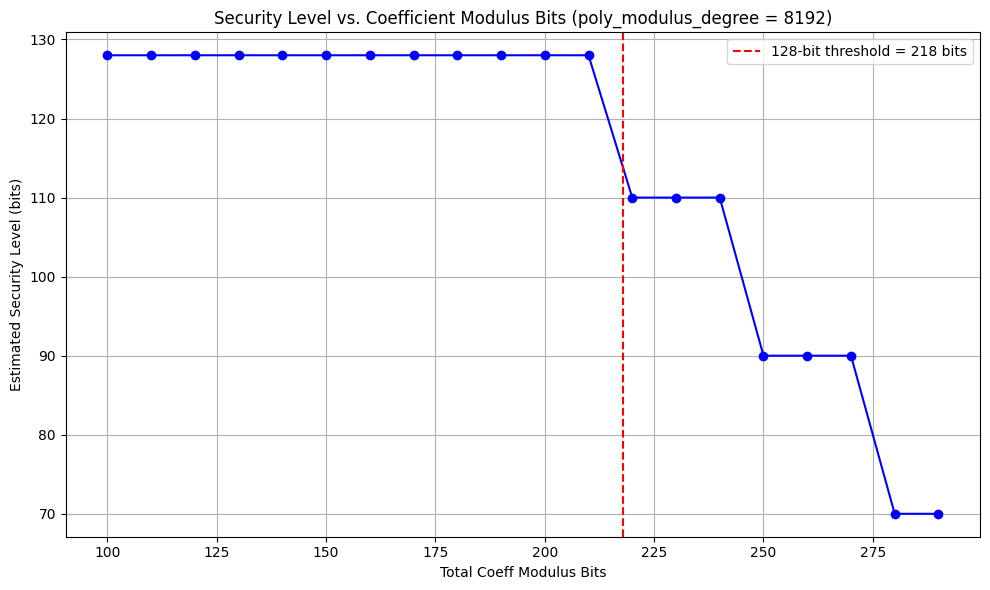

In [68]:
import matplotlib.pyplot as plt

# Security limits from Microsoft SEAL guidelines for 128-bit security
security_limits = {
    1024: 27,
    2048: 54,
    4096: 109,
    8192: 218,
    16384: 438,
    32768: 881
}

# Choose the poly modulus degree you're analyzing
poly_modulus_degree = 8192
max_allowed = security_limits[poly_modulus_degree]

# Try different total coeff_mod bit-lengths
coeff_bit_trials = list(range(100, 300, 10))  # Try total bits from 100 to 290
security_bits = []

# Estimate the security level based on how much the total bits exceed the threshold
for bits in coeff_bit_trials:
    if bits <= max_allowed:
        security_bits.append(128)  # Secure
    elif bits <= max_allowed + 30:
        security_bits.append(110)  # Slightly insecure
    elif bits <= max_allowed + 60:
        security_bits.append(90)   # Moderately insecure
    else:
        security_bits.append(70)   # Weak

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(coeff_bit_trials, security_bits, marker='o', linestyle='-', color='blue')
plt.axvline(x=max_allowed, color='red', linestyle='--', label=f"128-bit threshold = {max_allowed} bits")
plt.title("Security Level vs. Coefficient Modulus Bits (poly_modulus_degree = 8192)")
plt.xlabel("Total Coeff Modulus Bits")
plt.ylabel("Estimated Security Level (bits)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# New Homework📚

## graph (poly mod degree vary on the coefficient mod )

In [69]:
## change into many vectors
## calculate 
## do math operation on encrypted
## 3 clients
## 10000 elements
# start from the same elements and continue into vary size

# pesudo code
# vec1 = [1,2, ...]
# vec2 = [1, ...]
# vec3 = [21, ...]

# enc_vec1 = he(vec1)
# enc_vec2 = he(vec2)
# enc_vec3 = he(vec3)

# enc_avg_vec = (enc_vec1+enc_vec2+enc_vec3)/3
# dec_avg_vec = he_dec(enc_avg_vec)

# pt_avg_vec = (vec1+vec2+vec3)/3

# mse(dec_avg_vec, pt_avg_vec)


[+] Testing coeff_mod: [60, 22, 60]
Middle prime = 22, Using global scale = 2^40
[array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258]), array([0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
       0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914]), array([0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998,
       0.78517596, 0.19967378, 0.51423444, 0.59241457, 0.04645041])]
This encrypted vector:  [<tenseal.tensors.ckksvector.CKKSVector object at 0x124cec9d0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x12769d8b0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x127666340>]
1 Round 187579
2 Round 187871
3 Round 187732
plain: [0.33565917 0.68670601 0.61886041 0.39245315 0.26463786 0.37485833
 0.18733321 0.63505567 0.54182487 0.34858404]
after decrpyt:  [90464.65879502548, 185076.50051013206, 166791.20053894562, 105771.3994752081, 71323.46200641387, 101029.359647574

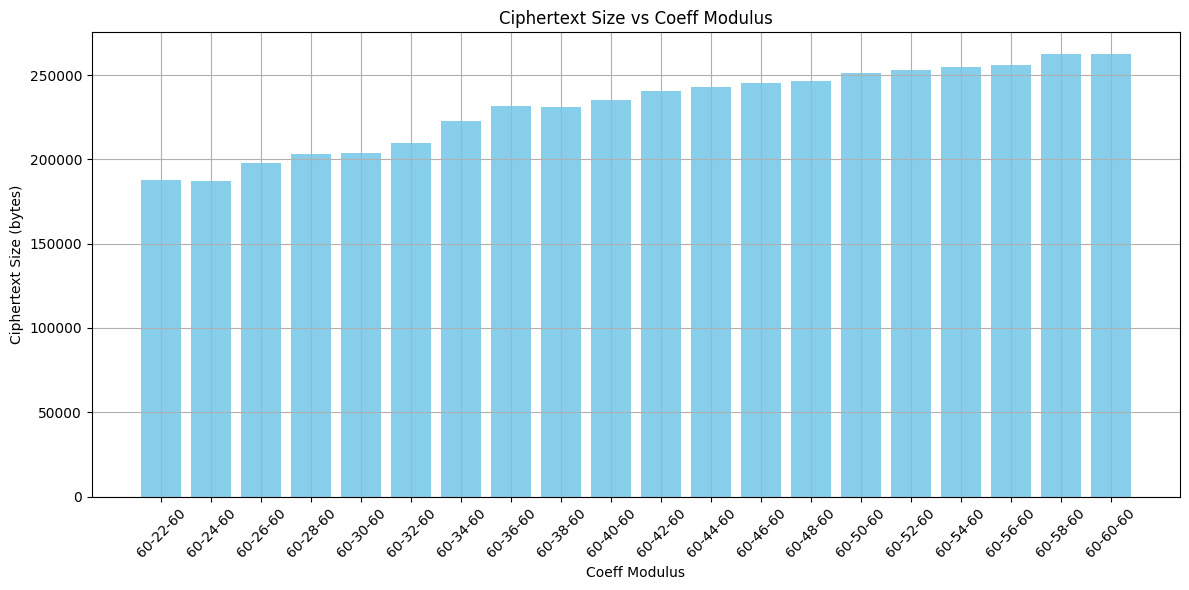

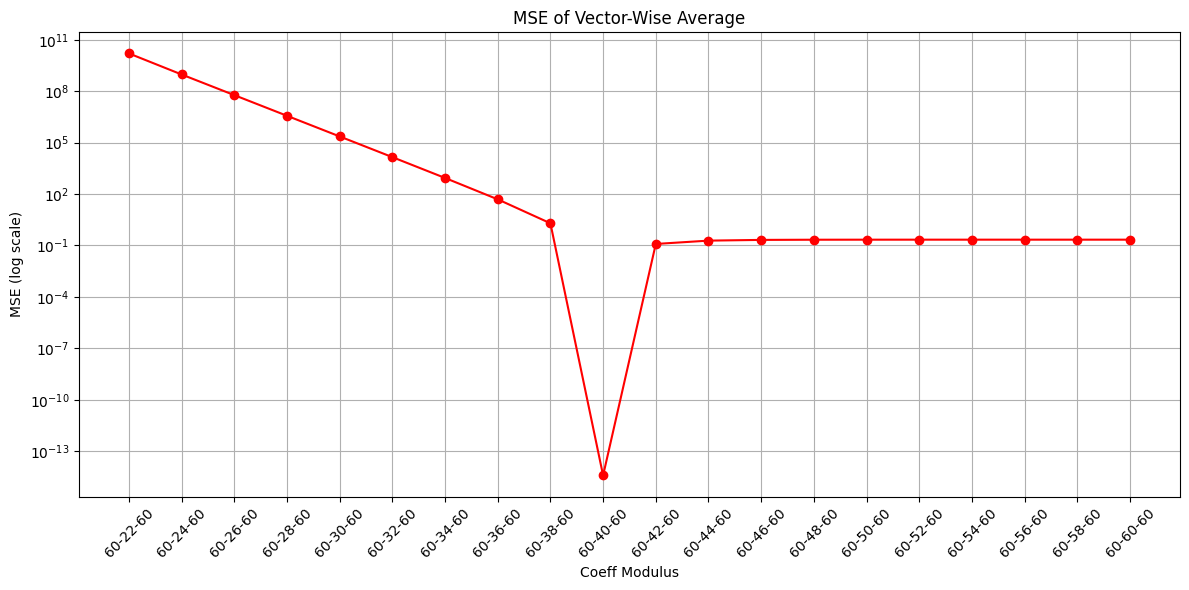


=== SUMMARY ===
True overall average (plaintext): 0.438597
Avg of decrypted HE average vector: 7828.433416
Absolute error: 7.827995e+03
Absolute error: 7.827995e+03

[+] Testing coeff_mod: [40, 22, 40]
Middle prime = 22, Using global scale = 2^30
[array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258]), array([0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
       0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914]), array([0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998,
       0.78517596, 0.19967378, 0.51423444, 0.59241457, 0.04645041])]
This encrypted vector:  [<tenseal.tensors.ckksvector.CKKSVector object at 0x114cbcbb0>, <tenseal.tensors.ckksvector.CKKSVector object at 0x13356f400>, <tenseal.tensors.ckksvector.CKKSVector object at 0x117c2c790>]
1 Round 159532
2 Round 159740
3 Round 158108
plain: [0.33565917 0.68670601 0.61886041 0.39245315 0.26463786 0.37485833
 0.1873332

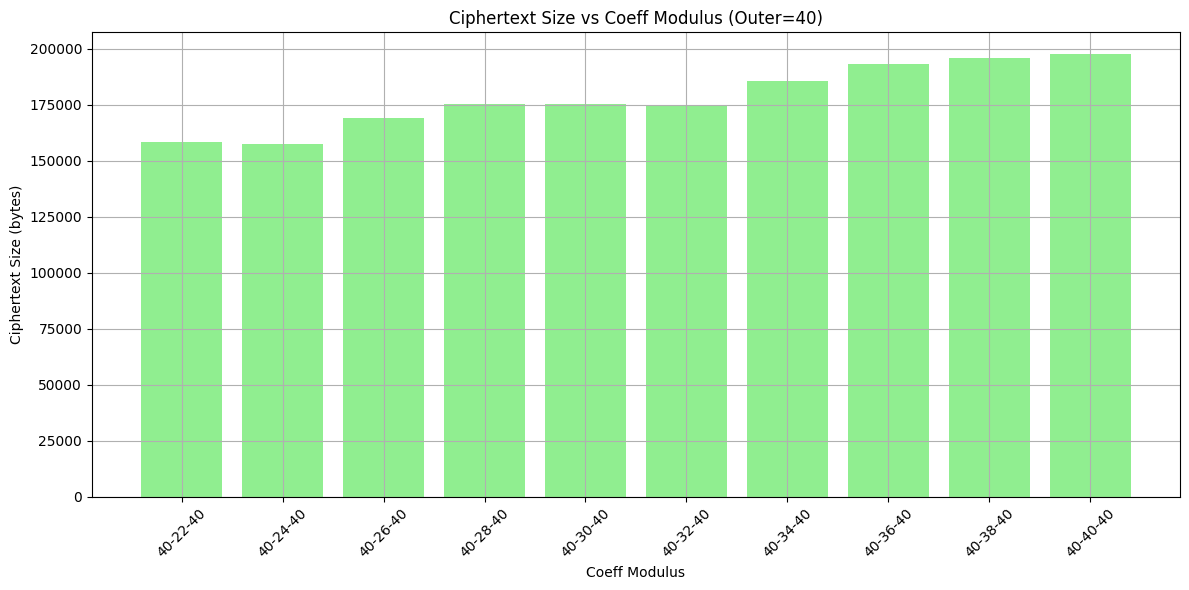

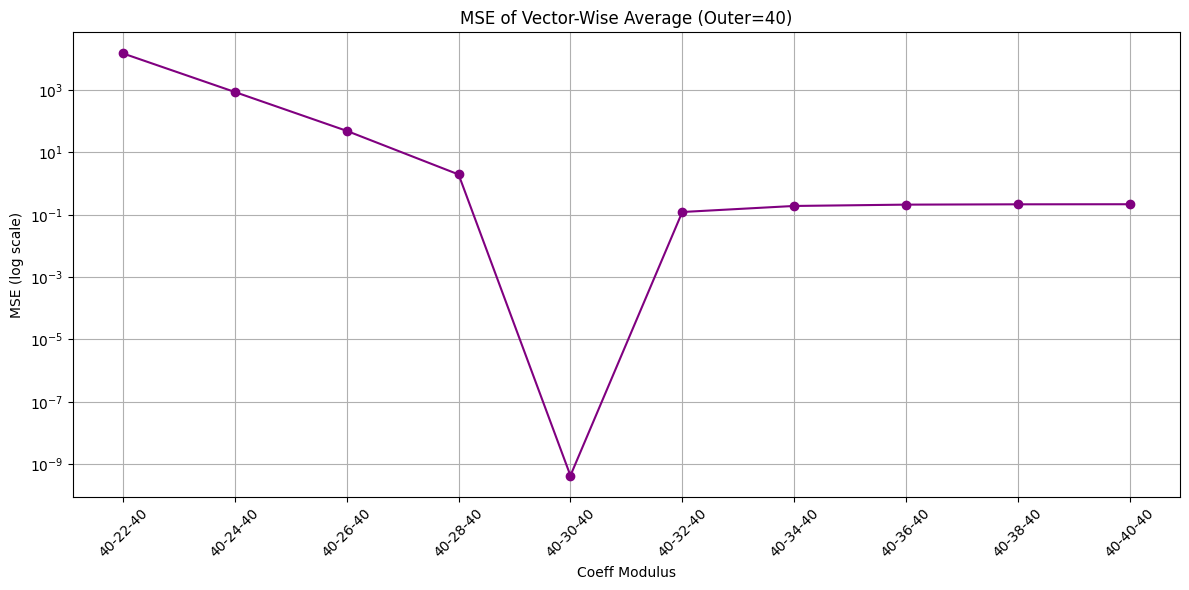

In [70]:
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import sys
import random
from time import time

# === Reproducibility ===
np.random.seed(42)
random.seed(42)

# === Parameters ===
poly_modulus_degree = 8192
vector_size = 10
num_vectors = 3
vectors = [np.random.rand(vector_size) for _ in range(num_vectors)]

# case 60
def generate_coeff_mods(start=22, stop=61, step=2):
    return [[60, mid, 60] for mid in range(start, stop, step)]

coeff_mods = generate_coeff_mods()
def generate_coeff_mods_outer_40(start=22, stop=41, step=2):
    return [[40, mid, 40] for mid in range(start, stop, step)]

coeff_mods_40 = generate_coeff_mods_outer_40()

def evaluate_vectorwise_average(coeff_mod_bits):
    print(f"\n[+] Testing coeff_mod: {coeff_mod_bits}")
    outer = coeff_mod_bits[0]
    middle_prime = coeff_mod_bits[1]

    if outer == 40:
        global_scale = 2 ** 30
    elif outer == 60:
        global_scale = 2 ** 40

    print(f"Middle prime = {middle_prime}, Using global scale = 2^{int(np.log2(global_scale))}")

    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bits,
    )
    context.global_scale = global_scale
    context.generate_galois_keys()

    # Encrypt vectors
    encrypted_vectors = [ts.ckks_vector(context, vec) for vec in vectors]
    print(vectors)
    print("This encrypted vector: ",encrypted_vectors)
    for i, vec in enumerate(encrypted_vectors, 1):
        print(i, "Round", len(vec.serialize()))

    # Homomorphic sum
    encrypted_sum = encrypted_vectors[0]
    for enc_vec in encrypted_vectors[1:]:
        encrypted_sum += enc_vec
    num_vectors = len(encrypted_vectors)
    # Average by scalar multiplication
    encrypted_avg = encrypted_sum * (1/ num_vectors)

    # Decrypt
    decrypted_avg_vec = encrypted_avg.decrypt()

    # Plaintext average vector
    plain_avg_vec = np.mean(vectors, axis=0)

    # MSE
    mse = np.mean((plain_avg_vec - decrypted_avg_vec) ** 2)

    # Ciphertext size
    size = len(encrypted_vectors[0].serialize())
    print("plain:",plain_avg_vec[:100])
    print("after decrpyt: ",decrypted_avg_vec[:100])

    return mse, size, decrypted_avg_vec, plain_avg_vec



mse_list, size_list, avg_list,no_he = [], [], [], []
for coeff_mod in coeff_mods:
    mse, size, avg ,pt= evaluate_vectorwise_average(coeff_mod)
    mse_list.append(mse)
    size_list.append(size)
    avg_list.append(avg)
    no_he.append(pt)


labels = [f"{c[0]}-{c[1]}-{c[2]}" for c in coeff_mods]

print("\n=== DETAILED RESULTS ===")
for i, label in enumerate(labels):
    print(f"[{label}]")
    print(f"  - Ciphertext size: {size_list[i]} bytes")
    print(f"  - Avg of decrypted HE vector: {avg_list[i]}")
    print(f"  - Avg of no HE vector: {no_he[i]}")
    print(f"  - MSE: {mse_list[i]:.6e}")
    print("")

# === Plotting ===

# Ciphertext sizes
plt.figure(figsize=(12, 6))
plt.bar(labels, size_list, color='skyblue')
plt.title('Ciphertext Size vs Coeff Modulus')
plt.ylabel('Ciphertext Size (bytes)')
plt.xlabel('Coeff Modulus')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# MSE
plt.figure(figsize=(12, 6))
plt.plot(labels, mse_list, marker='o', color='red')
plt.title('MSE of Vector-Wise Average')
plt.ylabel('MSE (log scale)')
plt.xlabel('Coeff Modulus')
plt.yscale('log')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# === Summary ===
print("\n=== SUMMARY ===")
true_avg_vec = np.mean(vectors, axis=0)
true_avg = np.mean(true_avg_vec)
he_avg = np.mean(avg_list)
print(f"True overall average (plaintext): {true_avg:.6f}")
print(f"Avg of decrypted HE average vector: {he_avg:.6f}")
print(f"Absolute error: {abs(he_avg - true_avg):.6e}")
print(f"Absolute error: {abs(he_avg - true_avg):.6e}")

# Run experiment for outer = 40
mse_list_40, size_list_40, avg_list_40, no_he_40 = [], [], [], []
for coeff_mod in coeff_mods_40:
    mse, size, avg, pt = evaluate_vectorwise_average(coeff_mod)
    mse_list_40.append(mse)
    size_list_40.append(size)
    avg_list_40.append(avg)
    no_he_40.append(pt)

# Plot outer=40 case
labels_40 = [f"{c[0]}-{c[1]}-{c[2]}" for c in coeff_mods_40]

# Ciphertext sizes
plt.figure(figsize=(12, 6))
plt.bar(labels_40, size_list_40, color='lightgreen')
plt.title('Ciphertext Size vs Coeff Modulus (Outer=40)')
plt.ylabel('Ciphertext Size (bytes)')
plt.xlabel('Coeff Modulus')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# MSE
plt.figure(figsize=(12, 6))
plt.plot(labels_40, mse_list_40, marker='o', color='purple')
plt.title('MSE of Vector-Wise Average (Outer=40)')
plt.ylabel('MSE (log scale)')
plt.xlabel('Coeff Modulus')
plt.yscale('log')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
print("\n=== SUMMARY (Outer=40) ===")
true_avg = np.mean(np.mean(vectors, axis=0))
he_avg_40 = np.mean([np.mean(v) for v in avg_list_40])
print(f"True overall average (plaintext): {true_avg:.6f}")
print(f"Avg of decrypted HE average vector (outer=40): {he_avg_40:.6f}")
print(f"Absolute error: {abs(he_avg_40 - true_avg):.6e}")



## Homework by using global scale based on middle prime


[+] Testing coeff_mod: [60, 18, 60]
Middle prime = 18, Outer = 60, Using global scale = 2^18
This is the size:  179764
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.5467865366454514, 1.04964649632857, 0.8021926610056036]

[+] Testing coeff_mod: [60, 20, 60]
Middle prime = 20, Outer = 60, Using global scale = 2^20
This is the size:  186751
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.3507012751978956, 0.6652886165546277, 0.5043323783461273]

[+] Testing coeff_mod: [60, 22, 60]
Middle prime = 22, Outer = 60, Using global scale = 2^22
This is the size:  187860
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.35308482806798136, 0.6755882634629333, 0.5103741978854387]

[+] Testing coeff_mod: [60, 24, 60]
Middle prime = 24, Outer = 60, Using global scale = 2^24
This is the size:  185020
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.34388334175283264, 0.6582435560962591, 0.4968348149993611]

[+] Testing coeff_mod: [60, 26, 60]
Middle prim

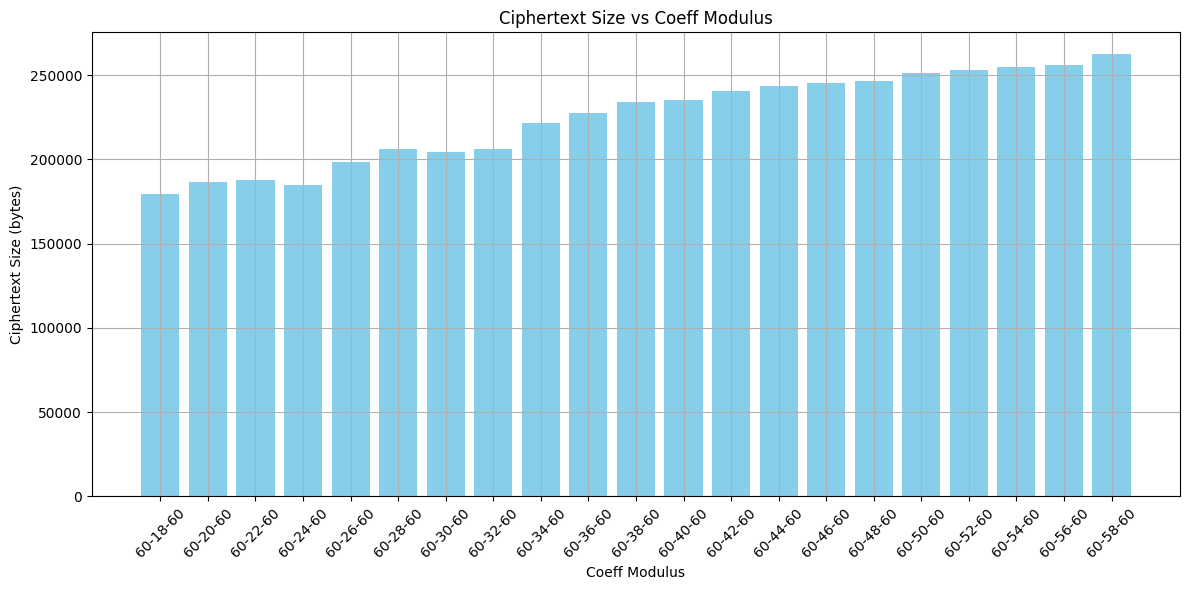

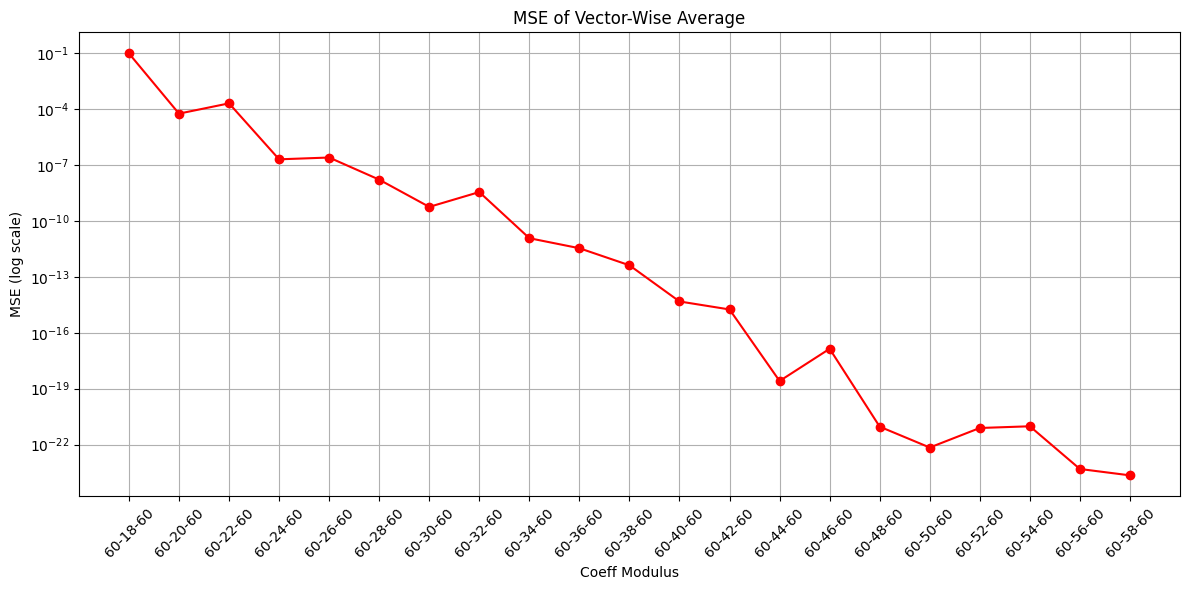


[+] Testing coeff_mod: [40, 22, 40]
Middle prime = 22, Outer = 40, Using global scale = 2^22
This is the size:  157868
size: 157868
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.35372356407297395, 0.6761454289522533, 0.5094956890062814]

[+] Testing coeff_mod: [40, 24, 40]
Middle prime = 24, Outer = 40, Using global scale = 2^24
This is the size:  157193
size: 157193
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.3440557848293623, 0.6581763755299626, 0.4968366375766937]

[+] Testing coeff_mod: [40, 26, 40]
Middle prime = 26, Outer = 40, Using global scale = 2^26
This is the size:  169782
size: 169782
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.3440977209663439, 0.6582660670726552, 0.496848782406014]

[+] Testing coeff_mod: [40, 28, 40]
Middle prime = 28, Outer = 40, Using global scale = 2^28
This is the size:  174856
size: 174856
plain: [0.34376074 0.65763636 0.49636782]
after decrypt: [0.34385416339222613, 0.657791953796555, 0.49648433607548

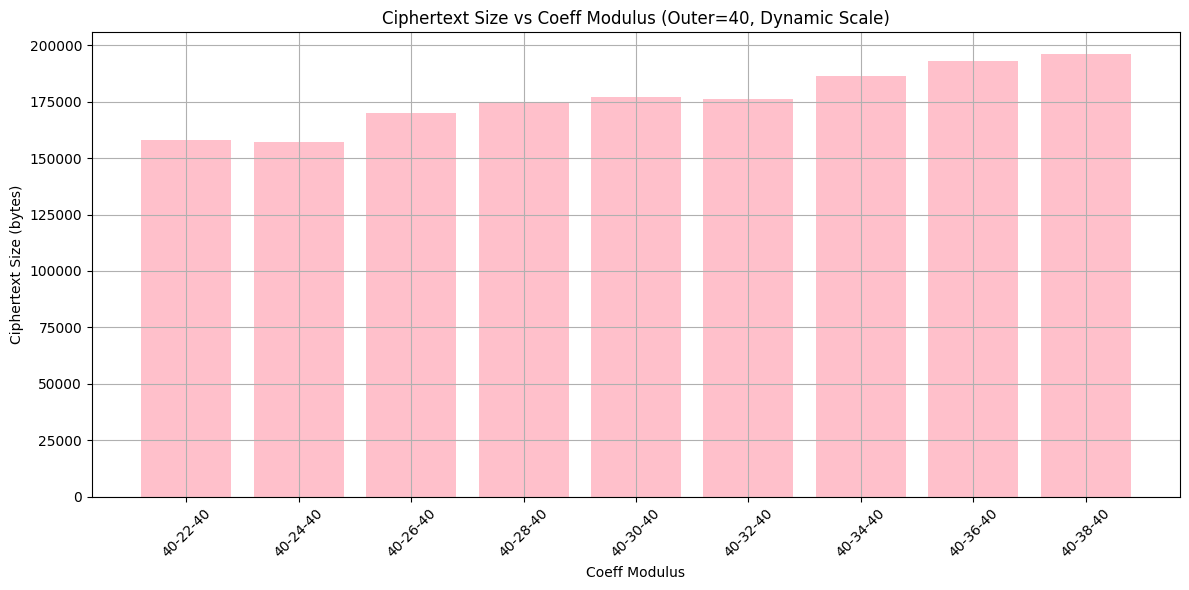

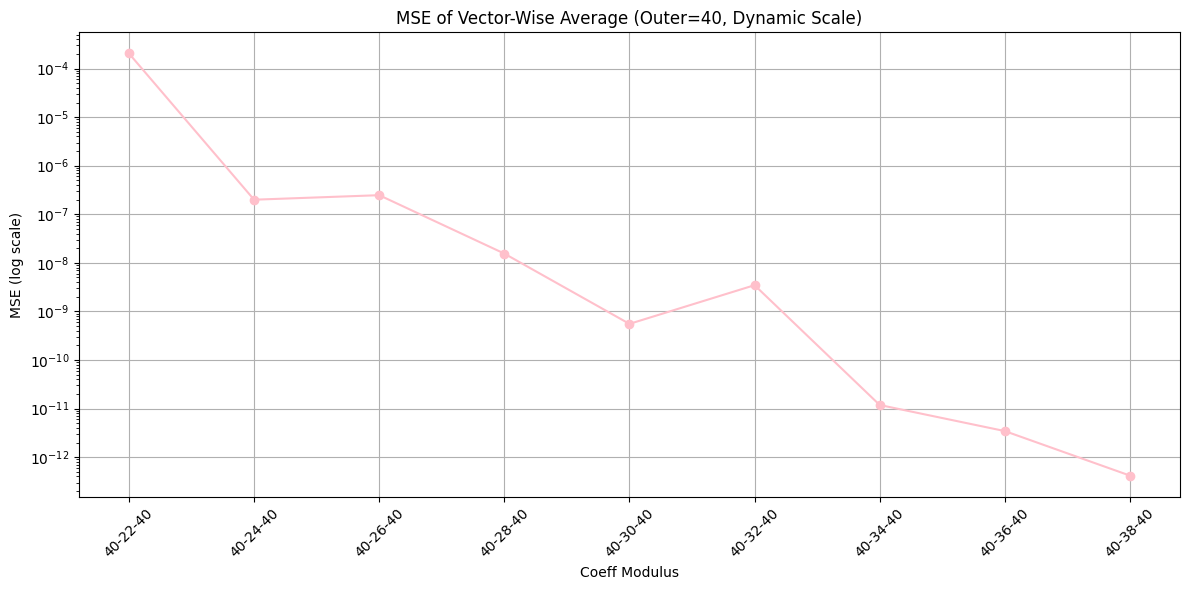

In [12]:
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import sys
import random
from time import time

# === Reproducibility ===
np.random.seed(42)
random.seed(42)

# === Parameters ===
poly_modulus_degree = 8192
vector_size = 3
num_vectors = 3
vectors = [np.random.rand(vector_size) for _ in range(num_vectors)]

def generate_coeff_mods(start=18, stop=59, step=2):
    return [[60, mid, 60] for mid in range(start, stop, step)]

coeff_mods = generate_coeff_mods()
def generate_coeff_mods_outer_40(start=22, stop=39, step=2):
    return [[40, mid, 40] for mid in range(start, stop, step)]

coeff_mods_40 = generate_coeff_mods_outer_40()



#  this is case: 60 idiot lmao
def evaluate_vectorwise_average_with_dynamic_scale(coeff_mod_bits):
    print(f"\n[+] Testing coeff_mod: {coeff_mod_bits}")
    outer = coeff_mod_bits[0]
    middle_prime = coeff_mod_bits[1]

    # Ensure exponent <= outer prime
    exponent = min(middle_prime, outer)
    global_scale = 2 ** exponent

    print(f"Middle prime = {middle_prime}, Outer = {outer}, Using global scale = 2^{exponent}")

    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bits,
    )
    context.global_scale = global_scale
    context.generate_galois_keys()

    # Encrypt vectors
    encrypted_vectors = [ts.ckks_vector(context, vec) for vec in vectors]

    # Homomorphic sum
    encrypted_sum = encrypted_vectors[0]
    for enc_vec in encrypted_vectors[1:]:
        encrypted_sum += enc_vec
    num_vectors = len(encrypted_vectors)
    # Average by scalar multiplication
    encrypted_avg = encrypted_sum * (1 / num_vectors)

    # Decrypt
    decrypted_avg_vec = encrypted_avg.decrypt()

    # Plaintext average vector
    plain_avg_vec = np.mean(vectors, axis=0)

    # MSE
    mse = np.mean((plain_avg_vec - decrypted_avg_vec) ** 2)

    # Ciphertext size
    size = len(encrypted_vectors[0].serialize())
    print("This is the size: ",size)
    print("plain:", plain_avg_vec[:100])
    print("after decrypt:", decrypted_avg_vec[:100])

    return mse, size, decrypted_avg_vec, plain_avg_vec


mse_list, size_list, avg_list, no_he = [], [], [], []
for coeff_mod in coeff_mods:
    mse, size, avg, pt = evaluate_vectorwise_average_with_dynamic_scale(coeff_mod)
    mse_list.append(mse)
    size_list.append(size)
    avg_list.append(avg)
    no_he.append(pt)


labels = [f"{c[0]}-{c[1]}-{c[2]}" for c in coeff_mods]

print("\n=== DETAILED RESULTS ===")
for i, label in enumerate(labels):
    print(f"[{label}]")
    print(f"  - Ciphertext size: {size_list[i]} bytes")
    print(f"  - Avg of decrypted HE vector: {avg_list[i]}")
    print(f"  - Avg of no HE vector: {no_he[i]}")
    print(f"  - MSE: {mse_list[i]:.6e}")
    print("")
# === Summary ===
print("\n=== SUMMARY ===")
true_avg_vec = np.mean(vectors, axis=0)
true_avg = np.mean(true_avg_vec)
he_avg = np.mean(avg_list)
print(f"True overall average (plaintext): {true_avg:.6f}")
print(f"Avg of decrypted HE average vector: {he_avg:.6f}")
print(f"Absolute error: {abs(he_avg - true_avg):.6e}")
print(f"Absolute error: {abs(he_avg - true_avg):.6e}")
# === Plotting ===

# Ciphertext sizes
plt.figure(figsize=(12, 6))
plt.bar(labels, size_list, color='skyblue')
plt.title('Ciphertext Size vs Coeff Modulus')
plt.ylabel('Ciphertext Size (bytes)')
plt.xlabel('Coeff Modulus')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

# MSE
plt.figure(figsize=(12, 6))
plt.plot(labels, mse_list, marker='o', color='red')
plt.title('MSE of Vector-Wise Average')
plt.ylabel('MSE (log scale)')
plt.xlabel('Coeff Modulus')
plt.yscale('log')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# this is case 40
def evaluate_vectorwise_average_dynamic_scale_40(coeff_mod_bits):
    print(f"\n[+] Testing coeff_mod: {coeff_mod_bits}")
    outer = coeff_mod_bits[0]
    middle_prime = coeff_mod_bits[1]

    # Ensure exponent <= outer prime
    exponent = min(middle_prime, outer)
    global_scale = 2 ** exponent

    print(f"Middle prime = {middle_prime}, Outer = {outer}, Using global scale = 2^{exponent}")

    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bits,
    )
    context.global_scale = global_scale
    context.generate_galois_keys()

    # Encrypt vectors
    encrypted_vectors = [ts.ckks_vector(context, vec) for vec in vectors]

    # Homomorphic sum
    encrypted_sum = encrypted_vectors[0]
    for enc_vec in encrypted_vectors[1:]:
        encrypted_sum += enc_vec
    num_vectors = len(encrypted_vectors)
    # Average by scalar multiplication
    encrypted_avg = encrypted_sum * (1 / num_vectors)

    # Decrypt
    decrypted_avg_vec = encrypted_avg.decrypt()

    # Plaintext average vector
    plain_avg_vec = np.mean(vectors, axis=0)

    # MSE
    mse = np.mean((plain_avg_vec - decrypted_avg_vec) ** 2)

    # Ciphertext size
    size = len(encrypted_vectors[0].serialize())
    print("This is the size: ",size)
    print("size:",size)
    print("plain:", plain_avg_vec[:100])
    print("after decrypt:", decrypted_avg_vec[:100])

    return mse, size, decrypted_avg_vec, plain_avg_vec


# Now run the experiment for outer=40 with dynamic scale:
mse_list_40, size_list_40, avg_list_40, no_he_40 = [], [], [], []
for coeff_mod in coeff_mods_40:
    mse, size, avg, pt = evaluate_vectorwise_average_dynamic_scale_40(coeff_mod)
    mse_list_40.append(mse)
    size_list_40.append(size)
    avg_list_40.append(avg)
    no_he_40.append(pt)



print("\n=== SUMMARY (Outer=40, Dynamic Scale) ===")
true_avg = np.mean(np.mean(vectors, axis=0))
he_avg_40 = np.mean([np.mean(v) for v in avg_list_40])
print(f"True overall average (plaintext): {true_avg:.6f}")
print(f"Avg of decrypted HE average vector (outer=40): {he_avg_40:.6f}")
print(f"Absolute error: {abs(he_avg_40 - true_avg):.6e}")

# Plot outer=40 case with dynamic scale
labels_40 = [f"{c[0]}-{c[1]}-{c[2]}" for c in coeff_mods_40]

plt.figure(figsize=(12, 6))
plt.bar(labels_40, size_list_40, color='pink')
plt.title('Ciphertext Size vs Coeff Modulus (Outer=40, Dynamic Scale)')
plt.ylabel('Ciphertext Size (bytes)')
plt.xlabel('Coeff Modulus')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.figure(figsize=(12, 6))
plt.plot(labels_40, mse_list_40, marker='o', color='pink')
plt.title('MSE of Vector-Wise Average (Outer=40, Dynamic Scale)')
plt.ylabel('MSE (log scale)')
plt.xlabel('Coeff Modulus')
plt.yscale('log')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## new homework testing on outer prime: ciphertext size


[+] Testing coeff_mod: [24, 22, 24]
Middle prime (fixed) = 22, Outer = 24, Using global scale = 2^22
Ciphertext size: 112559 bytes
Plain average vector (first 5 elems): [0.33565917 0.68670601 0.61886041 0.39245315 0.26463786]
Decrypted average vector (first 5 elems): [0.3449388741759563, 0.7059979985860897, 0.635867666053971, 0.4035577992622593, 0.27202827819094433]
MSE: 1.733675e-04

[+] Testing coeff_mod: [26, 22, 26]
Middle prime (fixed) = 22, Outer = 26, Using global scale = 2^22
Ciphertext size: 130902 bytes
Plain average vector (first 5 elems): [0.33565917 0.68670601 0.61886041 0.39245315 0.26463786]
Decrypted average vector (first 5 elems): [0.34607971645445723, 0.7062118363134615, 0.636291103864521, 0.40370650306394623, 0.27191956505591186]
MSE: 1.745428e-04

[+] Testing coeff_mod: [28, 22, 28]
Middle prime (fixed) = 22, Outer = 28, Using global scale = 2^22
Ciphertext size: 137335 bytes
Plain average vector (first 5 elems): [0.33565917 0.68670601 0.61886041 0.39245315 0.26463

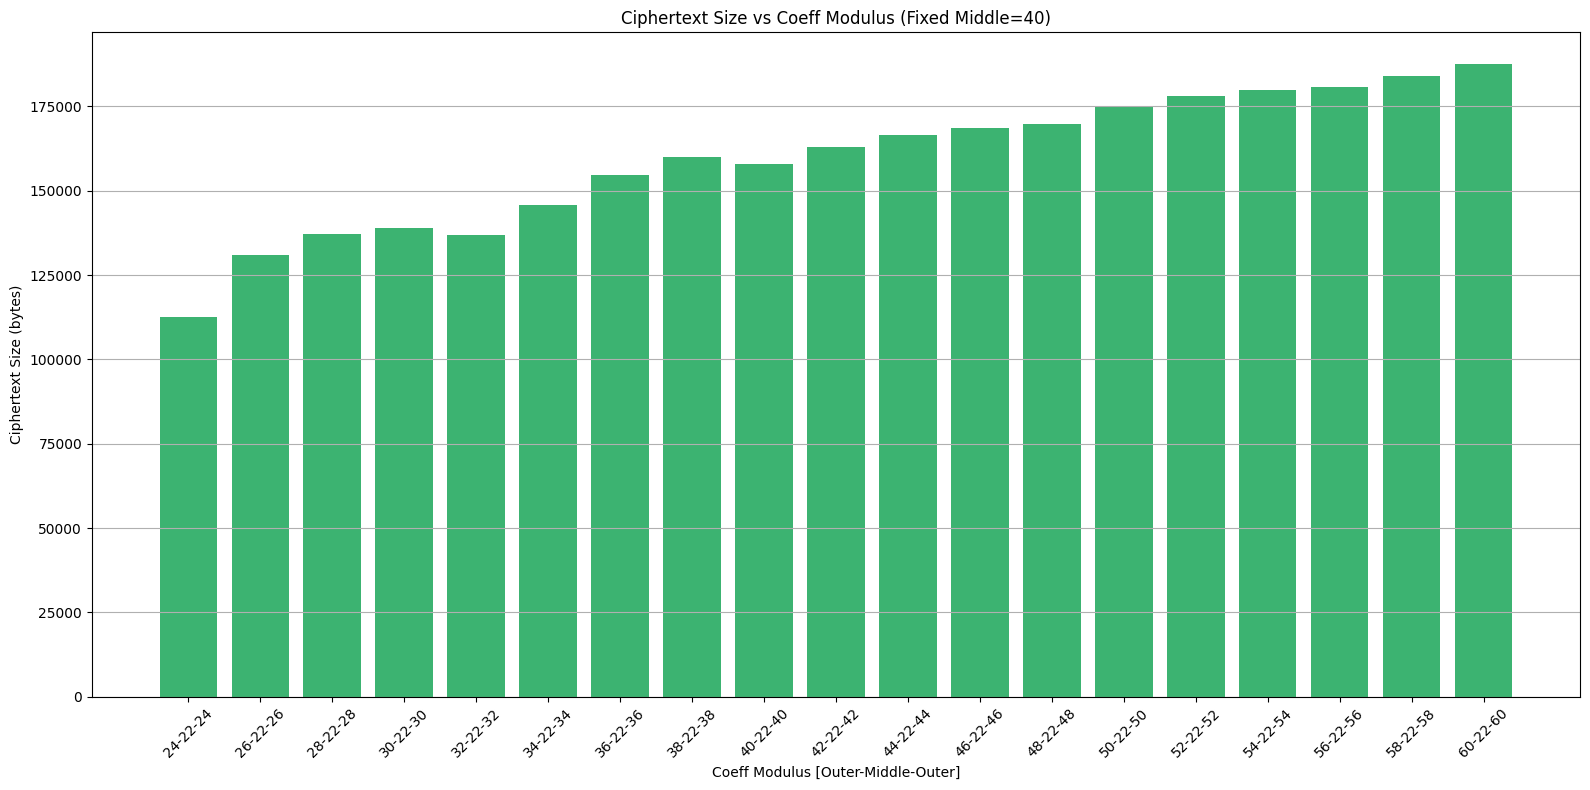

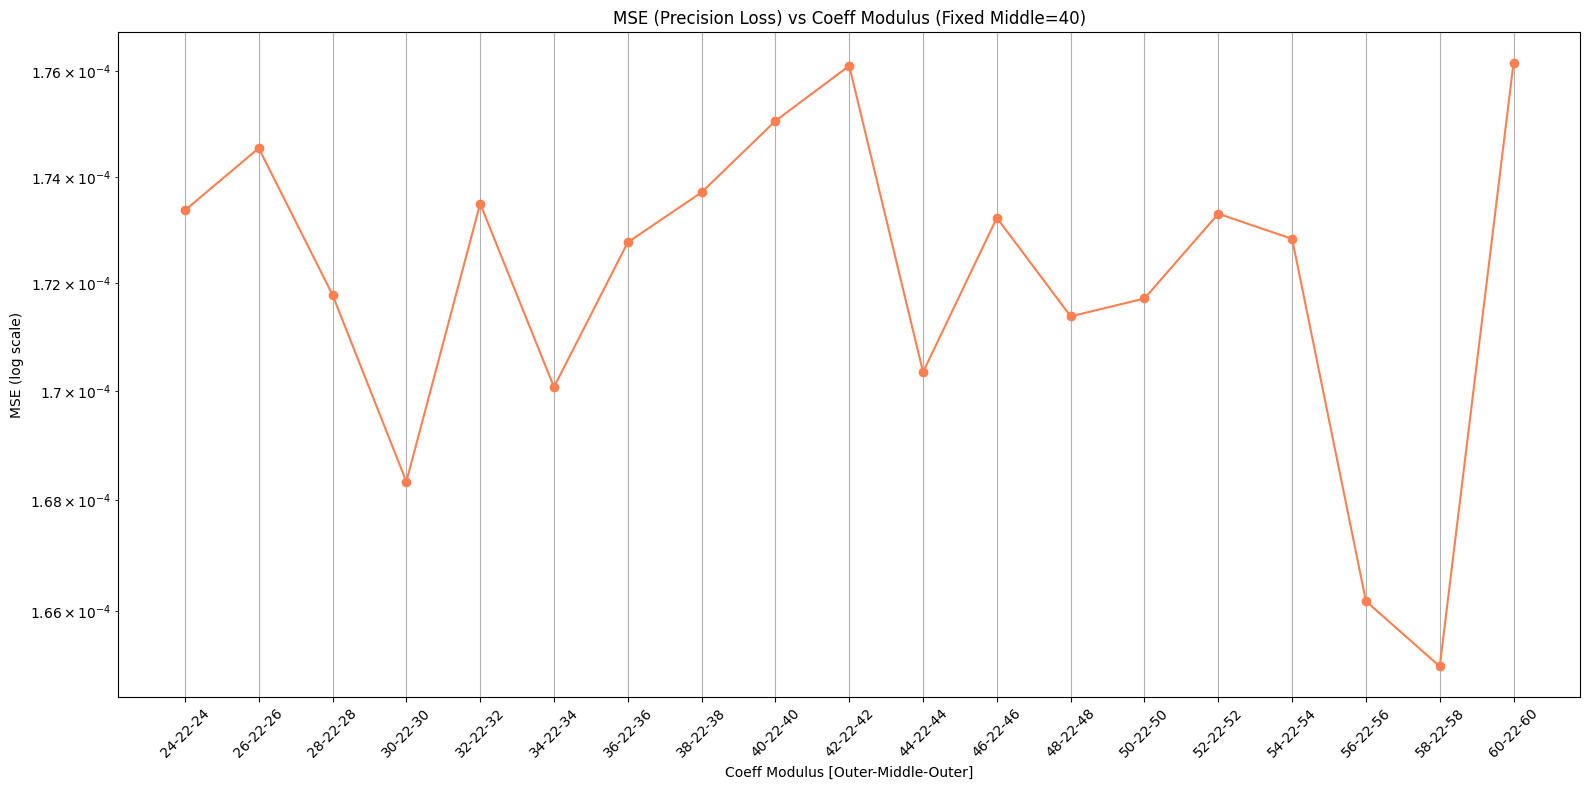

In [7]:
import tenseal as ts
import numpy as np
import matplotlib.pyplot as plt
import random

# === Reproducibility ===
np.random.seed(42)
random.seed(42)

# === Parameters ===
poly_modulus_degree = 8192
vector_size = 10
num_vectors = 3
vectors = [np.random.rand(vector_size) for _ in range(num_vectors)]

# Generate coeff_mods with fixed middle prime = 40 and outer from 44 to 60
def generate_coeff_mods_fixed_middle(middle=22, start=24, stop=62, step=2):
    return [[outer, middle, outer] for outer in range(start, stop, step)]

coeff_mods_fixed_middle = generate_coeff_mods_fixed_middle()

def evaluate_fixed_middle(coeff_mod_bits, fixed_middle=40):
    print(f"\n[+] Testing coeff_mod: {coeff_mod_bits}")
    outer = coeff_mod_bits[0]
    middle_prime = coeff_mod_bits[1]

    global_scale = 2 ** fixed_middle
    print(f"Middle prime (fixed) = {fixed_middle}, Outer = {outer}, Using global scale = 2^{fixed_middle}")

    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=coeff_mod_bits,
    )
    context.global_scale = global_scale
    context.generate_galois_keys()

    encrypted_vectors = [ts.ckks_vector(context, vec) for vec in vectors]

    encrypted_sum = encrypted_vectors[0]
    for enc_vec in encrypted_vectors[1:]:
        encrypted_sum += enc_vec

    encrypted_avg = encrypted_sum * (1 / len(encrypted_vectors))
    decrypted_avg_vec = encrypted_avg.decrypt()
    plain_avg_vec = np.mean(vectors, axis=0)
    mse = np.mean((plain_avg_vec - decrypted_avg_vec) ** 2)
    size = len(encrypted_vectors[0].serialize())

    print(f"Ciphertext size: {size} bytes")
    print(f"Plain average vector (first 5 elems): {plain_avg_vec[:5]}")
    print(f"Decrypted average vector (first 5 elems): {decrypted_avg_vec[:5]}")
    print(f"MSE: {mse:.6e}")

    return mse, size, decrypted_avg_vec, plain_avg_vec

# Run the tests
mse_list_fixed, size_list_fixed, avg_list_fixed, no_he_fixed = [], [], [], []

for coeff_mod in coeff_mods_fixed_middle:
    mse, size, avg, pt = evaluate_fixed_middle(coeff_mod, fixed_middle=22)
    mse_list_fixed.append(mse)
    size_list_fixed.append(size)
    avg_list_fixed.append(avg)
    no_he_fixed.append(pt)

# Prepare labels for plots
labels_fixed = [f"{c[0]}-{c[1]}-{c[2]}" for c in coeff_mods_fixed_middle]

## First plot (Ciphertext size)
plt.figure(figsize=(16, 8))
plt.bar(labels_fixed, size_list_fixed, color='mediumseagreen')
plt.title('Ciphertext Size vs Coeff Modulus (Fixed Middle=40)')
plt.ylabel('Ciphertext Size (bytes)')
plt.xlabel('Coeff Modulus [Outer-Middle-Outer]')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Second plot (MSE)
plt.figure(figsize=(16, 8))
plt.plot(labels_fixed, mse_list_fixed, marker='o', color='coral')
plt.title('MSE (Precision Loss) vs Coeff Modulus (Fixed Middle=40)')
plt.ylabel('MSE (log scale)')
plt.xlabel('Coeff Modulus [Outer-Middle-Outer]')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


[+] Testing global scale: 2^2 with coeff_mod [60, 40, 60]
Ciphertext size: 235414 bytes
MSE: 2.316215e+04

[+] Testing global scale: 2^4 with coeff_mod [60, 40, 60]
Ciphertext size: 235320 bytes
MSE: 4.683847e+03

[+] Testing global scale: 2^6 with coeff_mod [60, 40, 60]
Ciphertext size: 235354 bytes
MSE: 1.621152e+02

[+] Testing global scale: 2^8 with coeff_mod [60, 40, 60]
Ciphertext size: 235378 bytes
MSE: 1.434869e+00

[+] Testing global scale: 2^10 with coeff_mod [60, 40, 60]
Ciphertext size: 235366 bytes
MSE: 3.567677e+00

[+] Testing global scale: 2^12 with coeff_mod [60, 40, 60]
Ciphertext size: 235345 bytes
MSE: 7.097305e-01

[+] Testing global scale: 2^14 with coeff_mod [60, 40, 60]
Ciphertext size: 235332 bytes
MSE: 2.734241e-01

[+] Testing global scale: 2^16 with coeff_mod [60, 40, 60]
Ciphertext size: 235349 bytes
MSE: 2.586118e-01

[+] Testing global scale: 2^18 with coeff_mod [60, 40, 60]
Ciphertext size: 235343 bytes
MSE: 2.652851e-01

[+] Testing global scale: 2^20 

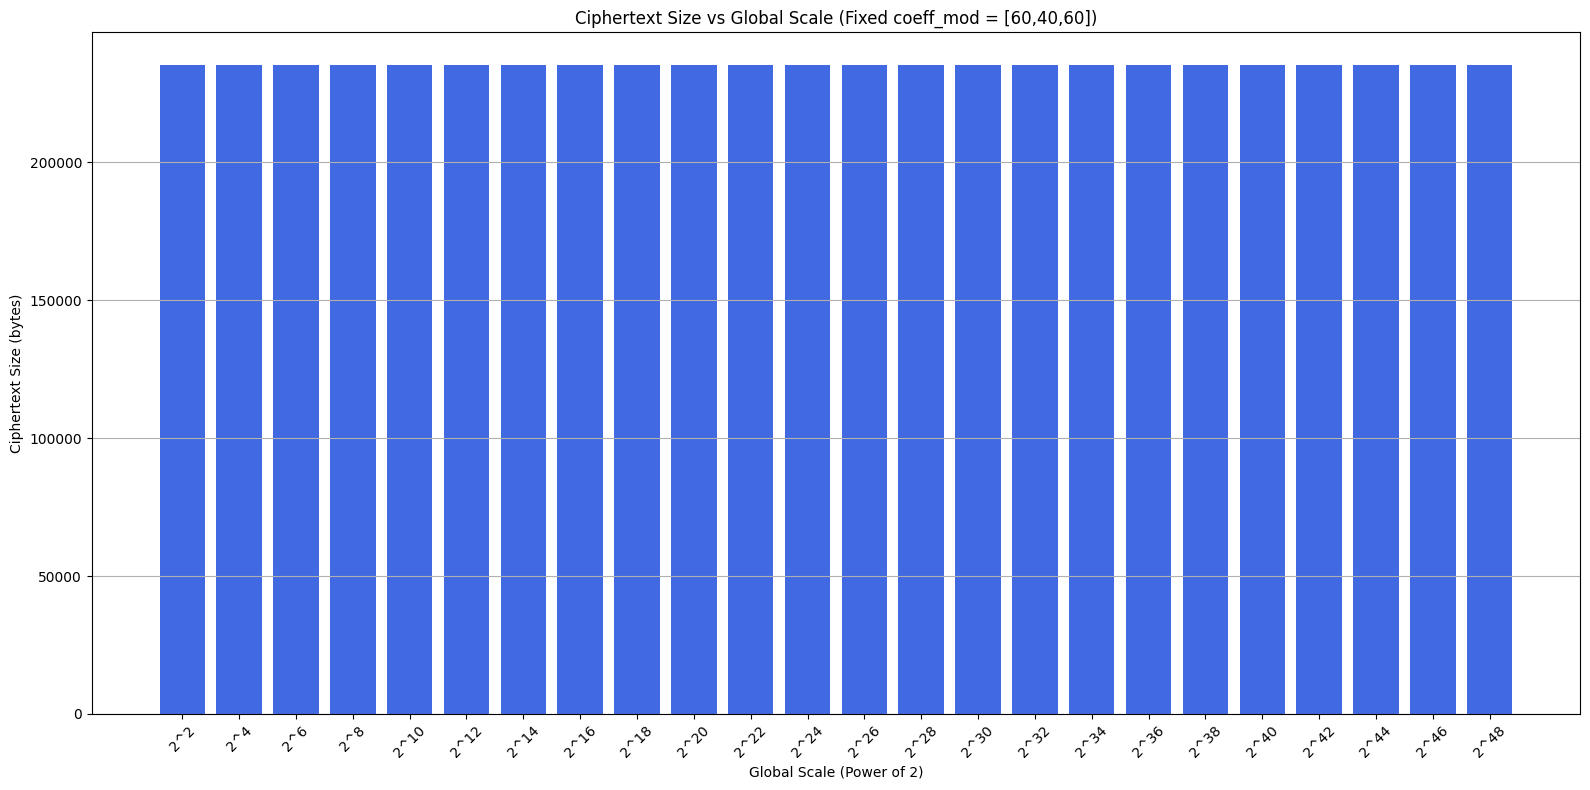

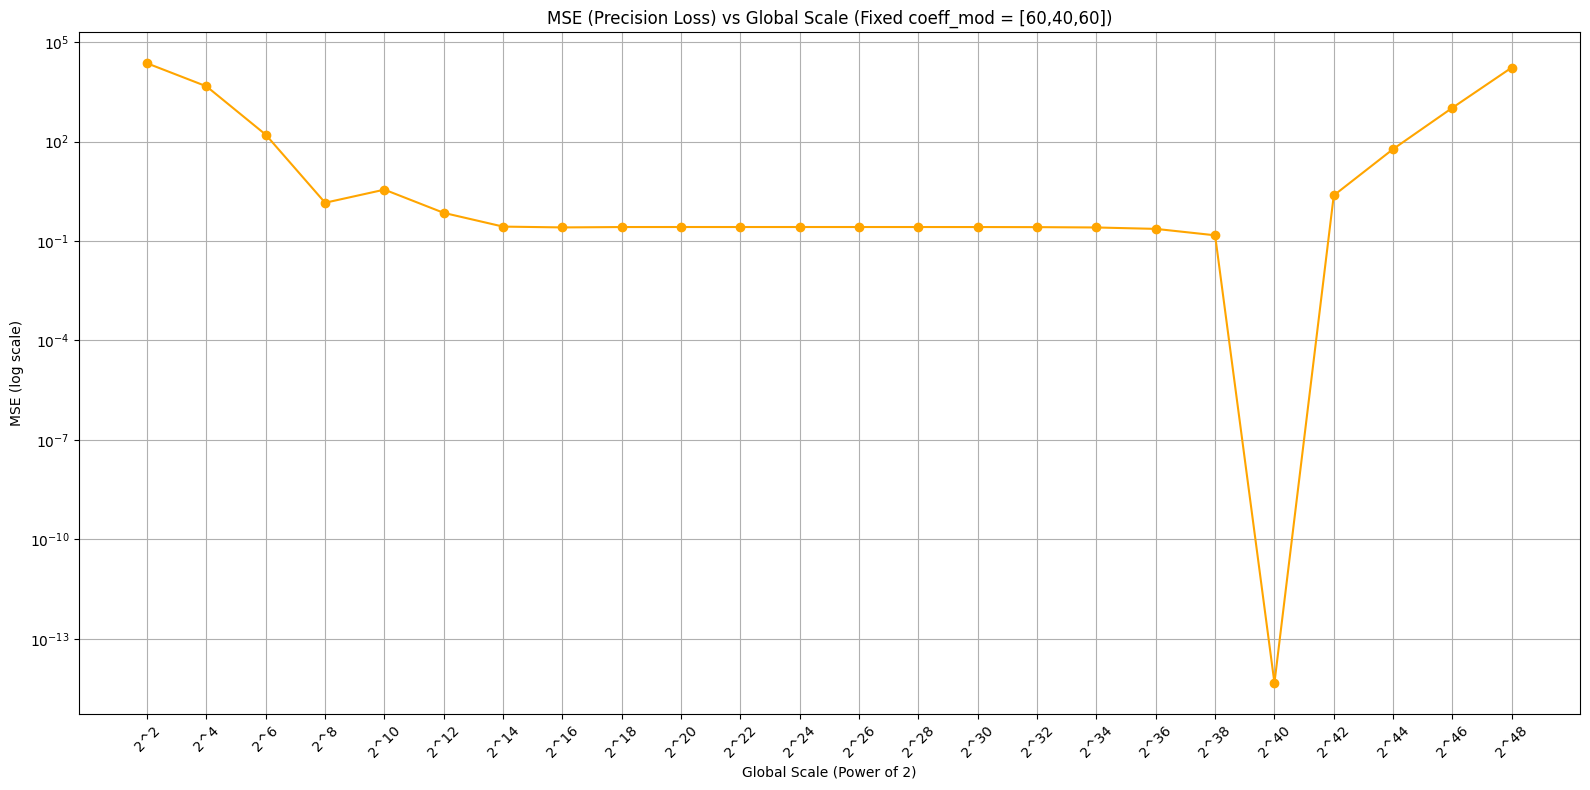

In [ ]:
fixed_coeff_mod = [60, 40, 60]
max_exp = 49  # max scale exponent capped here
global_scales = [2 ** exp for exp in range(2, max_exp + 1, 2)]  # 2^2 to 2^46

def evaluate_fixed_coeff_vary_scale(global_scale_exp):
    print(f"\n[+] Testing global scale: 2^{global_scale_exp} with coeff_mod {fixed_coeff_mod}")
    global_scale = 2 ** global_scale_exp

    context = ts.context(
        ts.SCHEME_TYPE.CKKS,
        poly_modulus_degree=poly_modulus_degree,
        coeff_mod_bit_sizes=fixed_coeff_mod,
    )
    context.global_scale = global_scale
    context.generate_galois_keys()

    encrypted_vectors = [ts.ckks_vector(context, vec) for vec in vectors]

    encrypted_sum = encrypted_vectors[0]
    for enc_vec in encrypted_vectors[1:]:
        encrypted_sum += enc_vec

    encrypted_avg = encrypted_sum * (1 / len(encrypted_vectors))
    decrypted_avg_vec = encrypted_avg.decrypt()
    plain_avg_vec = np.mean(vectors, axis=0)
    mse = np.mean((plain_avg_vec - decrypted_avg_vec) ** 2)
    size = len(encrypted_vectors[0].serialize())

    print(f"Ciphertext size: {size} bytes")
    print(f"MSE: {mse:.6e}")
    return mse, size

mse_scale_list = []
size_scale_list = []
exp_list = list(range(2, max_exp + 1, 2))

for exp in exp_list:
    try:
        mse, size = evaluate_fixed_coeff_vary_scale(exp)
        mse_scale_list.append(mse)
        size_scale_list.append(size)
    except Exception as e:
        print(f"Error at scale 2^{exp}: {e}")
        break

# Use only successful exponents for labels
scales_labels = [f"2^{exp}" for exp in exp_list[:len(mse_scale_list)]]

plt.figure(figsize=(16, 8))
plt.bar(scales_labels, size_scale_list, color='royalblue')
plt.title('Ciphertext Size vs Global Scale (Fixed coeff_mod = [60,40,60])')
plt.xlabel('Global Scale (Power of 2)')
plt.ylabel('Ciphertext Size (bytes)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 8))
plt.plot(scales_labels, mse_scale_list, marker='o', color='orange')
plt.title('MSE (Precision Loss) vs Global Scale (Fixed coeff_mod = [60,40,60])')
plt.xlabel('Global Scale (Power of 2)')
plt.ylabel('MSE (log scale)')
plt.yscale('log')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()




#  test experiment: 60+40+60 = 160 bits
#  global scale doesnt affect on ciphertext size

## More about TenSEALContext

TenSEALContext is holding more attributes than what we have seen so far, so it's worth mentioning some other interesting ones. The coolest attributes (at least to me) are the ones for setting automatic relinearization, rescaling (for CKKS only) and modulus switching. These features are enabled by default as you can see below:

In [73]:
print("Automatic relinearization is:", ("on" if context.auto_relin else "off"))
print("Automatic rescaling is:", ("on" if context.auto_rescale else "off"))
print("Automatic modulus switching is:", ("on" if context.auto_mod_switch else "off"))

Automatic relinearization is: on
Automatic rescaling is: on
Automatic modulus switching is: on


Experienced users can choose to disable one or more of these features and manage for themselves when and how to do these operations.

TenSEALContext can also hold a `global_scale` (only used when using CKKS), which is used as a default scale value when the user doesn't provide one. As most often users will define a single value to be used as scale during the entire HE computation, defining it globally can be more straight forward compared to passing it to every function call.

In [74]:
# this should throw an error as the global_scale isn't defined yet
try:
    print("global_scale:", context.global_scale)
except ValueError:
    print("The global_scale isn't defined yet")
    
# you can define it to 2 ** 20 for instance
context.global_scale = 2 ** 20
print("global_scale:", context.global_scale)

global_scale: 1099511627776.0
global_scale: 1048576.0


# Congratulations!!! - Time to Join the Community!

Congratulations on completing this notebook tutorial! If you enjoyed this and would like to join the movement towards privacy preserving, decentralized ownership of AI and the AI supply chain (data), you can do so in the following ways!

### Star TenSEAL on GitHub

The easiest way to help our community is just by starring the repos! This helps raise awareness of the cool tools we're building.

- [Star TenSEAL](https://github.com/OpenMined/TenSEAL)

### Join our Slack!

The best way to keep up to date on the latest advancements is to join our community! You can do so by filling out the form at [http://slack.openmined.org](http://slack.openmined.org).

### Donate

If you don't have time to contribute to our codebase, but would still like to lend support, you can also become a Backer on our Open Collective. All donations go towards our web hosting and other community expenses such as hackathons and meetups!

[OpenMined's Open Collective Page](https://opencollective.com/openmined)
